In [ ]:
# === Imports ===
# Standard library
import json
import math
import os
import re
from collections import defaultdict

# Third-party
import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
import nltk
import numpy as np
import pandas as pd
import seaborn as sb
from adjustText import adjust_text
from matplotlib.lines import Line2D
from scipy import stats
from sklearn import metrics
from transformers import AutoTokenizer

# Imports

Library imports, Google Drive mount, and the output directory for figures.
All plots in this notebook are written to `figures_dir` as PDF or PNG.


In [2]:
# GOOGLE DRIVE: mount Drive so the loader can read the similarities folder from
# "drive/MyDrive/...". If you instead keep the data locally in a flat folder
# (e.g. intermediate_outputs/similarities), you can SKIP this cell — see the
# alternative note in the data-loading cell below.
#
# Only needed for the Google-Drive version:
# from google.colab import drive
# drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
# Output directory for all figures produced below (PDF/PNG).
figures_dir = "drive/MyDrive/AMR/figures"
# figures_dir = "intermediate_outputs/figures"
os.makedirs(figures_dir, exist_ok=True)

# Metrics definitions

Core evaluation metric and shared helpers.

**TACC** (Translation Augmentation Contrastive Accuracy) is the fraction of items
where the model assigns a higher similarity to the true parallel translation
(`sim_parallel`) than to a perturbed negative / foil (`sim_x_neg`). Higher is better;
0.5 is chance.

`macro_tacc` macro-averages this: it computes TACC per group, then averages over the
four augmentation categories so no single augmentation type dominates.

The `wmt_to_cc100` map and `wmt_lang_to_tokens` helper are used later in the
training-data analysis; note that `wmt_lang_to_tokens` reads `cc100_tokens_m`, which
is defined further down in the "XLM-R Training Data" section.


In [4]:
# TACC: fraction of items where similarity to the true parallel (sims_pos)
# exceeds similarity to the negative/foil (sims_neg). Higher is better; 0.5 = chance.
def get_tacc(sims_pos, sims_neg):
    binary = [1 if sim_pos > sim_neg else 0 for sim_pos, sim_neg in zip(sims_pos, sims_neg)]
    return sum(binary) / len(binary)

In [5]:
# groupby-apply wrapper: returns TACC for one group as a Series.
def get_metrics(g):
    tacc = get_tacc(g['sim_parallel'], g['sim_x_neg'])
    return pd.Series({'tacc': tacc})

In [6]:
def macro_tacc(df, groupby_cols):
    """Compute TACC macro-averaged over aug_category."""
    if isinstance(groupby_cols, str):
        groupby_cols = [groupby_cols]
    per_aug = df.groupby(groupby_cols + ['aug_category']).apply(
        get_metrics, include_groups=False
    ).reset_index()
    result = per_aug.groupby(groupby_cols)['tacc'].mean().reset_index()
    return result

In [7]:
# WMT locale code -> CC-100 language code, plus a helper to look up CC-100
# token counts for a WMT language. NOTE: cc100_tokens_m is defined later, in the
# "XLM-R Training Data" section, so this helper only works once that cell has run.
# Map WMT lang codes to CC-100
wmt_to_cc100 = {
    'ar_EG': 'ar', 'bg_BG': 'bg', 'bn_IN': 'bn', 'ca_ES': 'ca',
    'cs_CZ': 'cs', 'da_DK': 'da', 'de_DE': 'de', 'el_GR': 'el',
    'es_MX': 'es', 'et_EE': 'et', 'fa_IR': 'fa', 'fi_FI': 'fi',
    'fil_PH': 'tl', 'fr_FR': 'fr', 'gu_IN': 'gu', 'he_IL': 'he',
    'hi_IN': 'hi', 'hr_HR': 'hr', 'hu_HU': 'hu', 'id_ID': 'id',
    'is_IS': 'is', 'it_IT': 'it', 'ja_JP': 'ja', 'kn_IN': 'kn',
    'ko_KR': 'ko', 'lt_LT': 'lt', 'lv_LV': 'lv', 'ml_IN': 'ml',
    'mr_IN': 'mr', 'nl_NL': 'nl', 'no_NO': 'no', 'pa_IN': 'pa',
    'pl_PL': 'pl', 'pt_BR': 'pt', 'ro_RO': 'ro', 'ru_RU': 'ru',
    'sk_SK': 'sk', 'sl_SI': 'sl', 'sr_RS': 'sr', 'sv_SE': 'sv',
    'sw_KE': 'sw', 'ta_IN': 'ta', 'te_IN': 'te', 'th_TH': 'th',
    'tr_TR': 'tr', 'uk_UA': 'uk', 'ur_PK': 'ur', 'vi_VN': 'vi',
    'zh_CN': 'zh_simp', 'zh_TW': 'zh_trad',
}

def wmt_lang_to_tokens(lang_code):
    cc100_key = wmt_to_cc100.get(lang_code)
    if cc100_key:
        return cc100_tokens_m.get(cc100_key)
    return None

In [8]:
# ============================================================
# SHARED LANGUAGE-CODE MAPPINGS
# ============================================================
# Recovered verbatim from an earlier version of this notebook (these cells were
# deleted before the analysis cells that use them). Defined here, before first use,
# so the notebook runs top-to-bottom. Used by the training-data, subtoken, and
# case-study cells. The LaTeX cell keeps its own uppercase WMT_TO_FLORES copy.

wmt_to_flores = {
    "ar_EG": "arb_Arab", "bg_BG": "bul_Cyrl", "bn_IN": "ben_Beng",
    "ca_ES": "cat_Latn", "cs_CZ": "ces_Latn", "da_DK": "dan_Latn",
    "de_DE": "deu_Latn", "el_GR": "ell_Grek", "es_MX": "spa_Latn",
    "et_EE": "est_Latn", "fa_IR": "pes_Arab", "fi_FI": "fin_Latn",
    "fil_PH": "tgl_Latn", "fr_FR": "fra_Latn", "gu_IN": "guj_Gujr",
    "he_IL": "heb_Hebr", "hi_IN": "hin_Deva", "hr_HR": "hrv_Latn",
    "hu_HU": "hun_Latn", "id_ID": "ind_Latn", "is_IS": "isl_Latn",
    "it_IT": "ita_Latn", "ja_JP": "jpn_Jpan", "kn_IN": "kan_Knda",
    "ko_KR": "kor_Hang", "lt_LT": "lit_Latn", "lv_LV": "lvs_Latn",
    "ml_IN": "mal_Mlym", "mr_IN": "mar_Deva", "nl_NL": "nld_Latn",
    "no_NO": "nob_Latn", "pa_IN": "pan_Guru", "pl_PL": "pol_Latn",
    "pt_BR": "por_Latn", "ro_RO": "ron_Latn", "ru_RU": "rus_Cyrl",
    "sk_SK": "slk_Latn", "sl_SI": "slv_Latn", "sr_RS": "srp_Cyrl",
    "sv_SE": "swe_Latn", "sw_KE": "swh_Latn", "ta_IN": "tam_Taml",
    "te_IN": "tel_Telu", "th_TH": "tha_Thai", "tr_TR": "tur_Latn",
    "uk_UA": "ukr_Cyrl", "ur_PK": "urd_Arab", "vi_VN": "vie_Latn",
    "zh_CN": "zho_Hans", "zh_TW": "zho_Hant", "zu_ZA": "zul_Latn",
}

# Reverse mapping for convenience
flores_to_wmt = {v: k for k, v in wmt_to_flores.items()}

# Human-readable language names for plotting
lang_names = {
    "ar_EG": "Arabic", "bg_BG": "Bulgarian", "bn_IN": "Bengali",
    "ca_ES": "Catalan", "cs_CZ": "Czech", "da_DK": "Danish",
    "de_DE": "German", "el_GR": "Greek", "es_MX": "Spanish",
    "et_EE": "Estonian", "fa_IR": "Persian", "fi_FI": "Finnish",
    "fil_PH": "Filipino", "fr_FR": "French", "gu_IN": "Gujarati",
    "he_IL": "Hebrew", "hi_IN": "Hindi", "hr_HR": "Croatian",
    "hu_HU": "Hungarian", "id_ID": "Indonesian", "is_IS": "Icelandic",
    "it_IT": "Italian", "ja_JP": "Japanese", "kn_IN": "Kannada",
    "ko_KR": "Korean", "lt_LT": "Lithuanian", "lv_LV": "Latvian",
    "ml_IN": "Malayalam", "mr_IN": "Marathi", "nl_NL": "Dutch",
    "no_NO": "Norwegian", "pa_IN": "Punjabi", "pl_PL": "Polish",
    "pt_BR": "Portuguese", "ro_RO": "Romanian", "ru_RU": "Russian",
    "sk_SK": "Slovak", "sl_SI": "Slovenian", "sr_RS": "Serbian",
    "sv_SE": "Swedish", "sw_KE": "Swahili", "ta_IN": "Tamil",
    "te_IN": "Telugu", "th_TH": "Thai", "tr_TR": "Turkish",
    "uk_UA": "Ukrainian", "ur_PK": "Urdu", "vi_VN": "Vietnamese",
    "zh_CN": "Chinese (Simp.)", "zh_TW": "Chinese (Trad.)", "zu_ZA": "Zulu",
}

# Data loading

Loads the per-item similarity scores produced by the evaluation runs.

**Expected layout** (see the loading cell below for both the Google Drive and the
flat-folder variants):

```
similarities/
  <augmentation_category>/
    <model__dataset>.json      # JSON-lines, one row per evaluated item
```

The loader builds a nested dict `dfs[aug_category][dataset][model_name] -> DataFrame`,
then flattens it into the three per-dataset frames used throughout the rest of the
notebook: `df_wmt` (ALEE-MT61), `df_flores` (ALEE-F200), and `df_bouquet` (ALEE-BQ275).


In [9]:
# ============================================================
# DATA LOADING — GOOGLE DRIVE (default)
# ============================================================
# Reads from a Google-Drive-mounted path. Expected layout:
#   <similarities_dir>/<aug_category>/<file>.json   (JSON-lines per model x dataset)
# Builds the nested dict: dfs[aug_category][dataset][model_name] = DataFrame.
# The trailing print()s are sanity checks on the nesting depth.
#
# --- Alternative: flat local folder "intermediate_outputs/similarities" ---
# If you are NOT on Google Drive and your files live in a flat folder structure
# under intermediate_outputs/similarities (same per-aug subfolders), set:
#
#     similarities_dir = "intermediate_outputs/similarities"
#
# The loop below is unchanged — it only needs similarities_dir to point at a
# directory whose immediate children are the augmentation-category subfolders,
# each containing the .json files. No Drive mount (cell with drive.mount) is
# required in that case.
dfs = {}
similarities_dir = "drive/MyDrive/AMR/similarities"
# similarities_dir = "intermediate_outputs/similarities"

for aug_category in os.listdir(similarities_dir):
    dfs[aug_category] = {}
    for file in os.listdir(os.path.join(similarities_dir, aug_category)):

        if not file.endswith('.json'):
            continue

        filepath = os.path.join(similarities_dir, aug_category, file)
        df = pd.read_json(filepath, lines=True)

        model_name = df['model'][0] if not "-" in df['model'][0] else df['model'][0].split('-')[0]
        df['model'] = model_name
        dataset = df['dataset'][0]

        if dataset in dfs[aug_category]:
            dfs[aug_category][dataset][model_name] = df
        else:
            dfs[aug_category][dataset] = {model_name: df}

print(len(dfs))
print(len(dfs[aug_category]))
print(len(dfs[aug_category][dataset]))
print(len(dfs[aug_category][dataset][model_name]))

4
3
14
93775


In [10]:
# Recreate table 3 from the monolingual paper.
# NOTE: builds merged_dfs but this object is not consumed elsewhere in the notebook.
# recreate table 3 in the monolingual paper: https://aclanthology.org/2025.emnlp-main.1343.pdf
merged_dfs = {}
for aug_category, datasets in dfs.items():
    merged_dfs[aug_category] = {}
    for dataset, model_dfs in datasets.items():
        merged_dfs[aug_category][dataset] = pd.concat(
            model_dfs.values(), ignore_index=True
        )

In [11]:
# Flatten the nested dfs dict into one DataFrame per dataset, tagging each row with
# its aug_category. These three frames (df_wmt / df_flores / df_bouquet) are the main
# inputs for the rest of the notebook.
dataset_dfs = defaultdict(list)

for aug_category, datasets in dfs.items():
    for dataset, model_dfs in datasets.items():
        for model_name, df in model_dfs.items():
            df = df.copy()
            df['aug_category'] = aug_category
            dataset_dfs[dataset].append(df)

df_wmt = pd.concat(dataset_dfs['wmt24pp'], ignore_index=True)
df_flores = pd.concat(dataset_dfs['flores200'], ignore_index=True)
df_bouquet = pd.concat(dataset_dfs['bouquet'], ignore_index=True)

# BQ275 / MT61: short vs long source text

Does TACC degrade as the source text gets longer (single sentence -> multi-sentence
-> paragraph)?

Length bins for ALEE-MT61 are defined by source-text character-count percentiles
(the cutoffs 115 and 315 chars correspond roughly to the P33 / P66 points printed by
the distribution cell). ALEE-BQ275 is split by its own `level` field instead.
The section reports per-bin macro-TACC, the size of the drop between bins, and whether
the model ranking stays stable across bins.


In [12]:
def length_bin_tacc(df, group='model'):
    """Macro-TACC for a length bin, matching the per-augmentation recipe:
    TACC per (model, lang, aug) -> average over languages -> macro over augs."""
    d = df.copy()
    d['lang'] = d['lang_pair'].str.replace('en_EN-', '', regex=False)
    per_cell = d.groupby([group, 'lang', 'aug_category']).apply(
        get_metrics, include_groups=False
    ).reset_index()
    per_aug = per_cell.groupby([group, 'aug_category'])['tacc'].mean().reset_index()  # over langs
    return per_aug.groupby(group)['tacc'].mean().reset_index()                         # over augs

In [13]:
# PLOT: macro-TACC by source-text length bin (single / multi / paragraph) for
# ALEE-MT61. Splits df_wmt at 115 and 315 chars, computes macro-TACC per bin per model,
# and draws a grouped horizontal bar chart. (Cutoffs match the percentiles above.)
# --- Split WMT by source text length (text_en) ---
df_wmt_single = df_wmt[df_wmt['text_en'].str.len() < 115].copy()
df_wmt_multi = df_wmt[(df_wmt['text_en'].str.len() >= 115) & (df_wmt['text_en'].str.len() < 315)].copy()
df_wmt_para = df_wmt[df_wmt['text_en'].str.len() >= 315].copy()

print(f"ALEE-MT61 single-sentence (<115 chars): {len(df_wmt_single)} rows")
print(f"ALEE-MT61 multi-sentence (115–314 chars): {len(df_wmt_multi)} rows")
print(f"ALEE-MT61 paragraph (>=315 chars): {len(df_wmt_para)} rows")

# --- Metrics ---
results_single = macro_tacc(df_wmt_single, ['model'])
results_multi = macro_tacc(df_wmt_multi, ['model'])
results_para = macro_tacc(df_wmt_para, ['model'])

# --- Merge results ---
table_len = (
    results_single[['model', 'tacc']]
    .merge(results_multi[['model', 'tacc']], on='model', suffixes=('_single', '_multi'))
    .merge(results_para[['model', 'tacc']], on='model')
    .rename(columns={
        'tacc_single': 'WMT_single',
        'tacc_multi': 'WMT_multi',
        'tacc': 'WMT_para'
    })
)

table_len['diff_para_single'] = table_len['WMT_para'] - table_len['WMT_single']
table_len = table_len.sort_values('diff_para_single', ascending=False).reset_index(drop=True)

print(table_len)

# --- Bar chart ---
fig, ax = plt.subplots(figsize=(12, max(6, len(table_len) * 0.4)))

models_sorted = table_len.sort_values('WMT_single', ascending=True)['model']
plot_df = table_len.set_index('model').loc[models_sorted]

y = range(len(plot_df))
bar_h = 0.25

ax.barh([i + bar_h for i in y], plot_df['WMT_single'], height=bar_h,
        label='Single sentence (≤P33 , <115Chars)', color='#0072B2', alpha=0.9)

ax.barh(y, plot_df['WMT_multi'], height=bar_h,
        label='Multi-sentence (P33–P66 , 115–314Chars)', color='#009E73', alpha=0.9)

ax.barh([i - bar_h for i in y], plot_df['WMT_para'], height=bar_h,
        label='Paragraph (>P66 >=315Chars)', color='#D55E00', alpha=0.9)

ax.legend(
    fontsize=14.5,          # This controls the "Single/Multi-sentence" text size
    loc='upper left',
    frameon=True          # Adds a box around legend to make text pop
)

ax.set_yticks(list(y))
ax.set_yticklabels(plot_df.index, fontsize=13.5)
ax.set_xlabel('ALEE-MT61 Macro-TACC', fontsize=22, fontweight='bold')
ax.tick_params(axis='x', labelsize=18)
ax.set_xlim(0.5, 1.0)

plt.tight_layout()
plt.savefig(f'{figures_dir}/wmt_textlen_performance--cell20.pdf', bbox_inches='tight')
plt.close()

ALEE-MT61 single-sentence (<115 chars): 549976 rows
ALEE-MT61 multi-sentence (115–314 chars): 562786 rows
ALEE-MT61 paragraph (>=315 chars): 573888 rows
                                model  WMT_single  WMT_multi  WMT_para  \
0         sentence_transformers_LaBSE    0.958789   0.919534  0.876232   
1          google_embeddinggemma_300m    0.907648   0.842612  0.802578   
2      multilingual_e5_large_instruct    0.957761   0.894982  0.850060   
3               multilingual_e5_large    0.945288   0.874351  0.835572   
4                         BAAI_bge_m3    0.945057   0.882189  0.832037   
5             nomic_embed_text_v2_moe    0.893685   0.825814  0.753047   
6                  jina_embeddings_v3    0.910034   0.817073  0.765457   
7       jina_embeddings_v5_text_small    0.892976   0.796024  0.746686   
8                multilingual_e5_base    0.930017   0.836554  0.768122   
9        jina_embeddings_v5_text_nano    0.883841   0.774411  0.721737   
10       paraphrase_multiL_mpnet_

In [14]:
# ============================================================
# ALEE-BQ275 PER-LEVEL TACC (sentence vs paragraph)
# ============================================================
# Builds `levels` (the distinct BQ275 source-text levels) and `table_lvl`
# (per-model macro-TACC split by level), used by the length-stats and
# performance-drop cells below. df_bouquet carries a `level` column whose values
# include sentence- and paragraph-level items.

# Distinct levels present in BQ275, ordered sentence-first when both are present.
_level_vals = list(df_bouquet['level'].dropna().unique())
_level_order = {'sentence': 0, 'paragraph': 1}
levels = sorted(_level_vals, key=lambda lv: _level_order.get(str(lv).lower(), 99))

# Per-model macro-TACC for each level, pivoted to one column per level.
_bq = df_bouquet.copy()
_bq_per_level = []
for lv in levels:
    sub = _bq[_bq['level'] == lv]
    res = macro_tacc(sub, ['model']).rename(columns={'tacc': f'BQ_{lv}_level'})
    _bq_per_level.append(res)

table_lvl = _bq_per_level[0]
for part in _bq_per_level[1:]:
    table_lvl = table_lvl.merge(part, on='model')

print(f"BQ275 levels: {levels}")
print(table_lvl.to_string(index=False))

BQ275 levels: ['sentence_level', 'paragraph_level']
                            model  BQ_sentence_level_level  BQ_paragraph_level_level
Alibaba_NLP_gte_multilingual_base                 0.808239                  0.653852
                      BAAI_bge_m3                 0.828395                  0.683650
       google_embeddinggemma_300m                 0.746637                  0.636912
    ibm_granite_embed_107m_multiL                 0.710209                  0.579423
    ibm_granite_embed_278m_multiL                 0.722458                  0.609235
               jina_embeddings_v3                 0.735129                  0.613333
     jina_embeddings_v5_text_nano                 0.697948                  0.533634
    jina_embeddings_v5_text_small                 0.700779                  0.535118
             multilingual_e5_base                 0.804378                  0.691378
            multilingual_e5_large                 0.818067                  0.731558
   multilingu

In [15]:
# ============================================================
# SOURCE TEXT LENGTH STATS per category — chars / words / tokens
# ============================================================

_token_re = re.compile(r"\w+|[^\w\s]")   # word-like runs OR standalone punctuation

def _measure(text, unit):
    if unit == 'chars':
        return len(text)
    elif unit == 'words':
        return len(text.split())
    elif unit == 'tokens':
        return len(_token_re.findall(text))

def length_stats(df, unit, text_col='text_en'):
    """Median, IQR, range of source-text length (in `unit`) over distinct texts."""
    texts = df.drop_duplicates(subset=[text_col])[text_col]
    lengths = texts.apply(lambda t: _measure(t, unit))
    q1, q3 = lengths.quantile(0.25), lengths.quantile(0.75)
    return {
        'n_texts': len(lengths),
        'median': lengths.median(),
        'q1': q1, 'q3': q3, 'iqr': q3 - q1,
        'min': lengths.min(), 'max': lengths.max(),
    }

def print_stats(name, s):
    print(f"{name:<34} n={s['n_texts']:>5}  "
          f"median={s['median']:>6.0f}  "
          f"IQR={s['iqr']:>6.0f} (Q1={s['q1']:.0f}, Q3={s['q3']:.0f})  "
          f"range=[{s['min']:.0f}, {s['max']:.0f}]")

# Bin/level definitions (computed once; the char cutoffs match the length analysis)
_len = df_wmt['text_en'].str.len()
mt61_groups = [
    ('Single (<115)',    df_wmt[_len < 115]),
    ('Multi (115–314)',  df_wmt[(_len >= 115) & (_len < 315)]),
    ('Paragraph (≥315)', df_wmt[_len >= 315]),
    ('All',              df_wmt),
]
bq_groups = [(lv, df_bouquet[df_bouquet['level'] == lv]) for lv in levels]
bq_groups.append(('All', df_bouquet))

# ---------- Three separate views ----------
for unit in ['chars', 'words', 'tokens']:
    print(f"\n{'='*72}")
    print(f"SOURCE TEXT LENGTH — {unit.upper()}")
    print(f"{'='*72}")

    print(f"\n--- ALEE-MT61 (by length bin) ---")
    for name, sub in mt61_groups:
        print_stats(name, length_stats(sub, unit))

    print(f"\n--- ALEE-BQ275 (by level) ---")
    for name, sub in bq_groups:
        print_stats(name, length_stats(sub, unit))


SOURCE TEXT LENGTH — CHARS

--- ALEE-MT61 (by length bin) ---
Single (<115)                      n=  329  median=    60  IQR=    43 (Q1=41, Q3=84)  range=[25, 114]
Multi (115–314)                    n=  261  median=   193  IQR=   118 (Q1=145, Q3=263)  range=[115, 314]
Paragraph (≥315)                   n=  213  median=   429  IQR=   155 (Q1=366, Q3=521)  range=[315, 967]
All                                n=  803  median=   150  IQR=   258 (Q1=69, Q3=328)  range=[25, 967]

--- ALEE-BQ275 (by level) ---
sentence_level                     n=  671  median=    67  IQR=    46 (Q1=47, Q3=93)  range=[25, 257]
paragraph_level                    n=  193  median=   301  IQR=   195 (Q1=216, Q3=411)  range=[58, 800]
All                                n=  864  median=    80  IQR=    95 (Q1=53, Q3=148)  range=[25, 800]

SOURCE TEXT LENGTH — WORDS

--- ALEE-MT61 (by length bin) ---
Single (<115)                      n=  329  median=    11  IQR=     8 (Q1=7, Q3=15)  range=[3, 25]
Multi (115–314)     

# Per-augmentation analysis

Macro-TACC broken down by augmentation type (antonym replacement, hypernym
substitution, polarity negation, role swap), per model and per dataset. Shows which
kinds of perturbation each model is best / worst at detecting.


In [16]:
# PLOT (bottom of cell): 3-panel horizontal bar chart, one panel per dataset
# (F200 / MT61 / BQ275), bars grouped by augmentation category.
# The cell first computes per-(model, aug) macro-TACC for each dataset (avg_by_aug).
# Per-dataset Macro-TACC over ALL languages each model was scored on.
# No overlap filtering, no cross-dataset joins: each dataset computed independently.
def _per_dataset_tacc(df, prefix):
    d = df.copy()
    d['lang'] = d['lang_pair'].str.replace(prefix, '', regex=False)
    return (d.groupby(['model', 'lang', 'aug_category'])
              .apply(get_metrics, include_groups=False)
              .reset_index())

results_flores_aug = _per_dataset_tacc(df_flores,  'eng_Latn-')
results_wmt_aug    = _per_dataset_tacc(df_wmt,     'en_EN-')
results_bouquet_aug = _per_dataset_tacc(df_bouquet, 'eng_Latn-')

print(f"ALEE-MT61 results: {len(results_wmt_aug)} rows")
print(f"ALEE-F200 results: {len(results_flores_aug)} rows")
print(f"ALEE-BQ275 results: {len(results_bouquet_aug)} rows")

# Macro over languages: per (model, aug_category), average across languages.
avg_by_aug = pd.concat([
    results_flores_aug.groupby(['model', 'aug_category'])['tacc'].mean().rename('flores'),
    results_wmt_aug.groupby(['model', 'aug_category'])['tacc'].mean().rename('wmt'),
    results_bouquet_aug.groupby(['model', 'aug_category'])['tacc'].mean().rename('bouquet'),
], axis=1).reset_index()

# --- plot ---
n_models = len(avg_by_aug['model'].unique())
fig, axes = plt.subplots(3, 1, figsize=(8, max(18, n_models * 0.45 * 3)))
for i, (ax, dataset, col) in enumerate(zip(axes, ['ALEE-F200', 'ALEE-MT61', 'ALEE-BQ275'], ['flores', 'wmt', 'bouquet'])):
    sub = avg_by_aug.pivot(index='model', columns='aug_category', values=col)
    sub = sub.loc[sub.mean(axis=1).sort_values(ascending=True).index]
    sub.plot.barh(ax=ax, width=0.8)
    ax.set_xlabel(f'{dataset} TACC', fontsize=20, fontweight='bold')
    ax.set_ylabel('', fontsize=18)
    ax.set_xlim(0.5, 1.0)
    ax.set_xticks([i / 10 for i in range(5, 11)])
    ax.set_xticklabels(['0.5', '0.6', '0.7', '0.8', '0.9', ''])
    ax.tick_params(axis='x', labelsize=18)
    ax.tick_params(axis='y', labelsize=12)
    ax.margins(x=0)
    if i == 0:
        ax.legend(title='Transformation', fontsize=10, title_fontsize=12, loc='lower left')
    else:
        ax.get_legend().remove()
plt.tight_layout(h_pad=1.2)
plt.savefig(f'{figures_dir}/aug_tacc_barh--cell39.png', bbox_inches='tight')
plt.close()

ALEE-MT61 results: 3416 rows
ALEE-F200 results: 11424 rows
ALEE-BQ275 results: 15400 rows


# XLM-R training data distribution vs performance

Tests whether per-language TACC correlates with how much pretraining data the
underlying XLM-R encoder saw for that language.

Two proxies for "how much data" are used: CC-100 pretraining token counts (this
section) and, further down, Common Crawl web-page rank tiers. Scatter plots are
produced separately for ALEE-F200, ALEE-MT61, and ALEE-BQ275, with points marked by
script and colored by cross-dataset membership.


In [17]:
# CC-100 pretraining data token counts (Millions) from the XLM-R paper.
# NOTE: Ukrainian and Swedish appear swapped/misprinted in the original table.
#   uk listed as 6.5M tokens / 84.6 GiB — corrected to 6500M.
#   sv listed as 77.8M tokens / 12.1 GiB — corrected to 7780M.
cc100_tokens_m = {
    'af': 242, 'am': 68, 'ar': 2869, 'as': 5, 'az': 783,
    'be': 362, 'bg': 5487, 'bn': 525, 'br': 16, 'bs': 14,
    'ca': 1752, 'cs': 2498, 'cy': 141, 'da': 7823, 'de': 10297,
    'el': 4285, 'en': 55608, 'eo': 157, 'es': 9374, 'et': 843,
    'eu': 270, 'fa': 13259, 'fi': 6730, 'fr': 9780, 'fy': 29,
    'ga': 86, 'gd': 21, 'gl': 495, 'gu': 140, 'ha': 56,
    'he': 3399, 'hi': 1715, 'hr': 3297, 'hu': 7807, 'hy': 421,
    'id': 22704, 'is': 505, 'it': 4983, 'ja': 530, 'jv': 24,
    'ka': 469, 'kk': 476, 'km': 36, 'kn': 169, 'ko': 5644,
    'ku': 66, 'ky': 94, 'la': 390, 'lo': 17, 'lt': 1835,
    'lv': 1198, 'mg': 25, 'mk': 449, 'ml': 313, 'mn': 248,
    'mr': 175, 'ms': 1318, 'my': 56, 'ne': 237, 'nl': 5025,
    'no': 8494, 'om': 8, 'or': 36, 'pa': 68, 'pl': 6490,
    'ps': 96, 'pt': 8405, 'ro': 10354, 'ru': 23408, 'sa': 17,
    'sd': 50, 'si': 243, 'sk': 3525, 'sl': 1669, 'so': 62,
    'sq': 918, 'sr': 843, 'su': 10, 'sv': 7780, 'sw': 275,
    'ta': 595, 'te': 249, 'th': 1834, 'tl': 556, 'tr': 2736,
    'ug': 27, 'uk': 6500, 'ur': 730, 'uz': 91, 'vi': 24757,
    'xh': 13, 'yi': 34,
    'zh_simp': 259, 'zh_trad': 176,
}

# FLORES ISO 639-3 code -> CC-100 ISO 639-1 code
# Only languages that have a CC-100 counterpart are included.
flores_iso3_to_cc100 = {
    'afr': 'af', 'amh': 'am', 'arb': 'ar', 'ars': 'ar', 'arz': 'ar',
    'ary': 'ar', 'acm': 'ar', 'acq': 'ar', 'apc': 'ar', 'ajp': 'ar', 'aeb': 'ar',
    'asm': 'as', 'azj': 'az', 'azb': 'az',
    'bel': 'be', 'bul': 'bg', 'ben': 'bn', 'bos': 'bs',
    'cat': 'ca', 'ces': 'cs', 'cym': 'cy', 'dan': 'da', 'deu': 'de',
    'ell': 'el', 'epo': 'eo', 'spa': 'es', 'est': 'et',
    'eus': 'eu', 'pes': 'fa', 'prs': 'fa', 'fin': 'fi', 'fra': 'fr',
    'fry': 'fy', 'gle': 'ga', 'gla': 'gd', 'glg': 'gl', 'guj': 'gu',
    'hau': 'ha', 'heb': 'he', 'hin': 'hi', 'hrv': 'hr', 'hun': 'hu',
    'hye': 'hy', 'ind': 'id', 'isl': 'is', 'ita': 'it', 'jpn': 'ja',
    'jav': 'jv', 'kat': 'ka', 'kaz': 'kk', 'khm': 'km', 'kan': 'kn',
    'kor': 'ko', 'kmr': 'ku', 'kir': 'ky', 'lao': 'lo', 'lit': 'lt',
    'lvs': 'lv', 'plt': 'mg', 'mkd': 'mk', 'mal': 'ml', 'khk': 'mn',
    'mar': 'mr', 'zsm': 'ms', 'mya': 'my', 'npi': 'ne', 'nld': 'nl',
    'nob': 'no', 'nno': 'no', 'gaz': 'om', 'ory': 'or', 'pan': 'pa',
    'pol': 'pl', 'pbt': 'ps', 'por': 'pt', 'ron': 'ro', 'rus': 'ru',
    'san': 'sa', 'snd': 'sd', 'sin': 'si', 'slk': 'sk', 'slv': 'sl',
    'som': 'so', 'sqi': 'sq', 'als': 'sq', 'srp': 'sr', 'sun': 'su',
    'swe': 'sv', 'swh': 'sw', 'tam': 'ta', 'tel': 'te', 'tha': 'th',
    'tgl': 'tl', 'tur': 'tr', 'uig': 'ug', 'ukr': 'uk', 'urd': 'ur',
    'uzn': 'uz', 'vie': 'vi', 'xho': 'xh', 'ydd': 'yi',
    'zho_Hans': 'zh_simp', 'zho_Hant': 'zh_trad',
}

# The set of FLORES lang codes that are also in WMT (for colour coding)
flores_codes_in_wmt = set(wmt_to_flores.values())  # e.g. {'arb_Arab', 'bul_Cyrl', ...}

In [18]:
# Build per-language TACC tables for ALEE-F200 and ALEE-BQ275, attach CC-100 token
# counts, and flag each language by CC-100 / WMT membership. Also derives the WMT-only
# languages that have no FLORES and no CC-100 counterpart.
# Depends on wmt_to_flores (defined elsewhere); ensure it is in scope before running.
df_flores_cc = df_flores.copy()
df_flores_cc['flores_lang'] = df_flores_cc['lang_pair'].str.replace('eng_Latn-', '')

def flores_to_cc100_tokens(flores_code):
    """Map a FLORES-style code like 'deu_Latn' to CC-100 token count."""
    iso3 = flores_code.split('_')[0]
    if flores_code == 'zho_Hans':
        return cc100_tokens_m.get('zh_simp')
    elif flores_code == 'zho_Hant':
        return cc100_tokens_m.get('zh_trad')
    cc100_key = flores_iso3_to_cc100.get(iso3)
    if cc100_key:
        return cc100_tokens_m.get(cc100_key)
    return None

# Per-language FLORES metrics across all models and augmentations
perf_flores_all = macro_tacc(df_flores_cc, ['flores_lang'])

perf_flores_all['tokens_m'] = perf_flores_all['flores_lang'].apply(flores_to_cc100_tokens)
perf_flores_all['in_wmt'] = perf_flores_all['flores_lang'].isin(flores_codes_in_wmt)
perf_flores_all['in_cc100'] = perf_flores_all['tokens_m'].notna()
perf_flores_all['label'] = perf_flores_all['flores_lang']

has_cc100 = perf_flores_all.dropna(subset=['tokens_m']).copy()
no_cc100 = perf_flores_all[perf_flores_all['tokens_m'].isna()].copy()
has_cc100['log_tokens'] = np.log10(has_cc100['tokens_m'])

# Per-language BOUQUET metrics across all models and augmentations
df_bouquet_cc = df_bouquet.copy()
df_bouquet_cc['flores_lang'] = df_bouquet_cc['lang_pair'].str.replace('eng_Latn-', '')

perf_bouquet_all = macro_tacc(df_bouquet_cc, ['flores_lang'])

perf_bouquet_all['tokens_m'] = perf_bouquet_all['flores_lang'].apply(flores_to_cc100_tokens)
perf_bouquet_all['in_wmt'] = perf_bouquet_all['flores_lang'].isin(flores_codes_in_wmt)
perf_bouquet_all['in_cc100'] = perf_bouquet_all['tokens_m'].notna()
perf_bouquet_all['label'] = perf_bouquet_all['flores_lang']

has_cc100_bq = perf_bouquet_all.dropna(subset=['tokens_m']).copy()
no_cc100_bq = perf_bouquet_all[perf_bouquet_all['tokens_m'].isna()].copy()
has_cc100_bq['log_tokens'] = np.log10(has_cc100_bq['tokens_m'])

# --- WMT-only languages (not in FLORES, not in CC-100) ---
df_wmt_tmp = df_wmt.copy()
df_wmt_tmp['wmt_lang'] = df_wmt_tmp['lang_pair'].str.replace('en_EN-', '')

# WMT langs that have no FLORES counterpart
wmt_langs_in_flores = set(wmt_to_flores.keys())
all_wmt_langs = set(df_wmt_tmp['wmt_lang'].unique())
wmt_only_langs = all_wmt_langs - wmt_langs_in_flores

# Check which of those are also missing from CC-100
def wmt_lang_in_cc100(wmt_code):
    """Check if a ALEE-MT61 lang code like 'de_DE' has CC-100 data."""
    iso2 = wmt_code.split('_')[0].lower()
    return iso2 in cc100_tokens_m

wmt_only_no_cc100 = {lang for lang in wmt_only_langs if not wmt_lang_in_cc100(lang)}

perf_wmt_only = macro_tacc(df_wmt_tmp[df_wmt_tmp['wmt_lang'].isin(wmt_only_no_cc100)], ['wmt_lang'])

print(f"Total ALEE-F200 languages: {len(perf_flores_all)}")
print(f"  With CC-100 data: {len(has_cc100)}")
print(f"    Of which also in ALEE-MT61: {has_cc100['in_wmt'].sum()}")
print(f"  Without CC-100 data: {len(no_cc100)}")
print(f"\nTotal ALEE-BQ275 languages: {len(perf_bouquet_all)}")
print(f"  With CC-100 data: {len(has_cc100_bq)}")
print(f"  Without CC-100 data: {len(no_cc100_bq)}")
print(f"\nALEE-MT61-only languages (not in ALEE-F200, not in CC-100): {len(wmt_only_no_cc100)}")
if len(perf_wmt_only) > 0:
    print(perf_wmt_only[['wmt_lang', 'tacc']].to_string(index=False))

Total ALEE-F200 languages: 204
  With CC-100 data: 102
    Of which also in ALEE-MT61: 50
  Without CC-100 data: 102

Total ALEE-BQ275 languages: 275
  With CC-100 data: 94
  Without CC-100 data: 181

ALEE-MT61-only languages (not in ALEE-F200, not in CC-100): 6
wmt_lang     tacc
   rm_PU 0.716698
   rm_RG 0.746200
   rm_SM 0.711579
   rm_ST 0.700191
   rm_SV 0.729310
   rm_VA 0.723784


In [19]:
# NOTE: Only needed for the Colab / Google-Drive version.
# For local runs, install dependencies from requirements.txt instead.
# Install adjustText (label de-overlapping) used by the publication-quality
# scatter plots in the following cells.
# !pip3 install adjustText

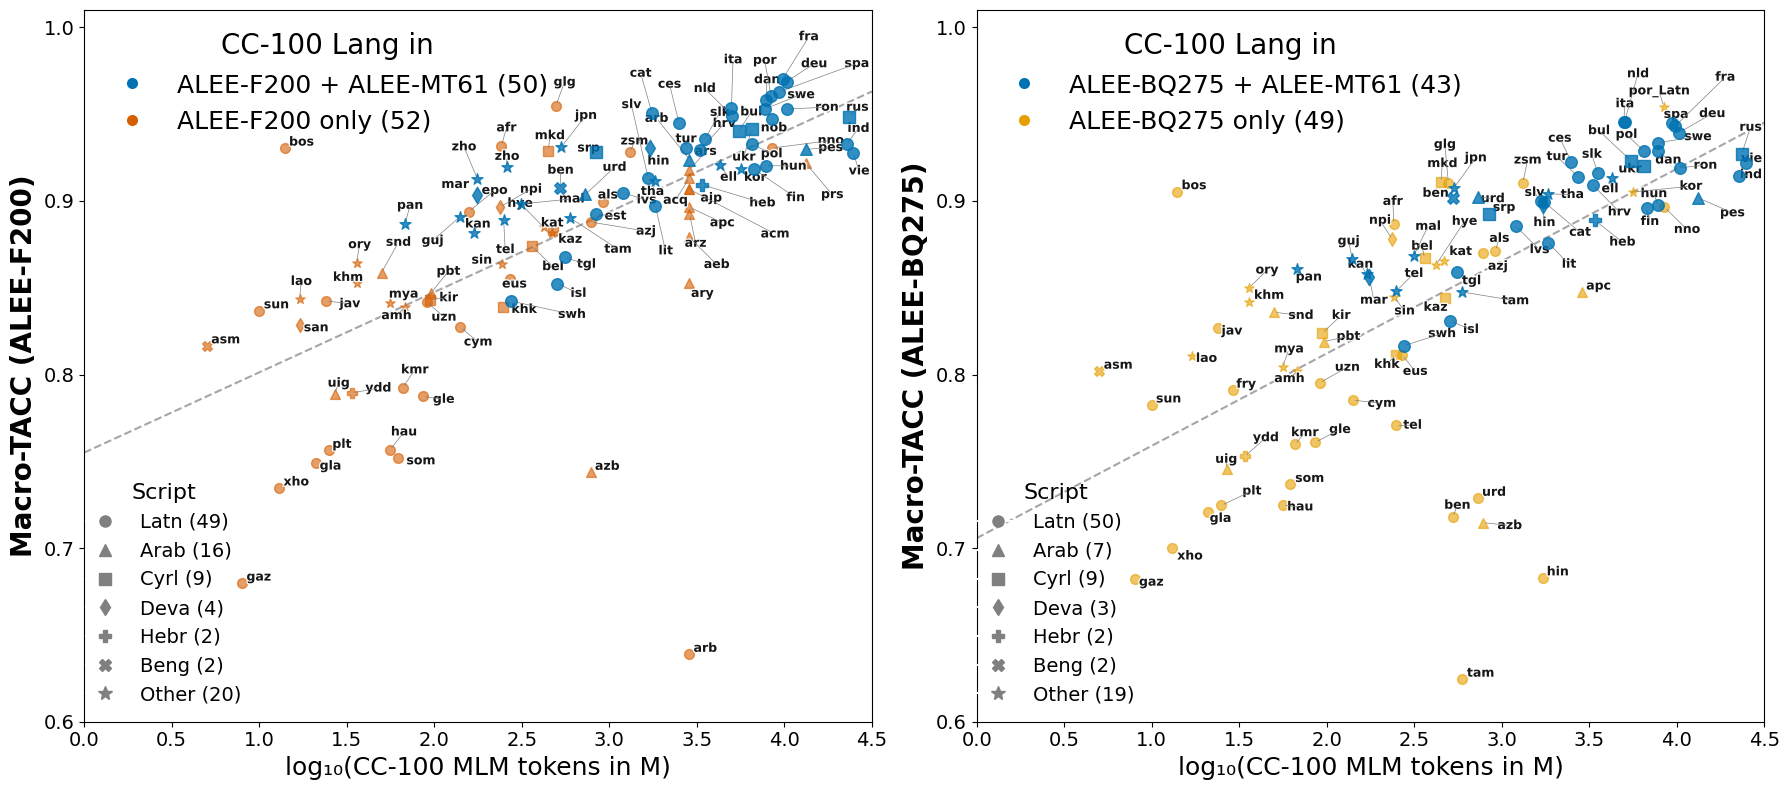

In [20]:
# PLOT: two-panel publication version of the CC-100-vs-TACC scatter
# (ALEE-F200 left, ALEE-BQ275 right) with adjustText label spreading and shared axes.

fig, (ax1, ax3) = plt.subplots(1, 2, figsize=(18, 8))  # side-by-side

SCRIPT_MARKERS = {
    'Latn': 'o',
    'Arab': '^',
    'Cyrl': 's',
    'Deva': 'd',
    'Hebr': 'P',
    'Beng': 'X',
}
OTHER_MARKER = '*'

LABEL_STROKE = [pe.withStroke(linewidth=2, foreground='white')]
LABEL_FONTSIZE = 9

# =========================================================
# LEFT PANEL — ALEE-F200
# =========================================================

has_cc100['script'] = has_cc100['flores_lang'].apply(
    lambda x: x.split('_')[-1] if '_' in x else 'Unknown'
)
has_cc100['short_label'] = has_cc100['flores_lang'].apply(
    lambda x: x.rsplit('_', 1)[0] if '_' in x else x
)

both = has_cc100[has_cc100['in_wmt']]
flores_only = has_cc100[~has_cc100['in_wmt']]

# Scatter
for _, row in has_cc100.iterrows():
    marker = SCRIPT_MARKERS.get(row['script'], OTHER_MARKER)
    color = '#0072B2' if row['in_wmt'] else '#D55E00'
    alpha = 0.8 if row['in_wmt'] else 0.6
    s = 70 if row['in_wmt'] else 50

    ax1.scatter(row['log_tokens'], row['tacc'],
                alpha=alpha, s=s, c=color, marker=marker,
                zorder=4 if row['in_wmt'] else 3)

# Labels (spread to avoid overlap)
texts1 = [
    ax1.text(row['log_tokens'], row['tacc'], row['short_label'],
             fontsize=LABEL_FONTSIZE, fontweight='bold', alpha=0.9, path_effects=LABEL_STROKE)
    for _, row in has_cc100.iterrows()
]

# Regression line
z = np.polyfit(has_cc100['log_tokens'], has_cc100['tacc'], 1)
x_line = np.linspace(0.0, 4.5, 100)
ax1.plot(x_line, np.polyval(z, x_line), '--', color='0.5', alpha=0.7)

# Category legend (top-left)
cat_handles = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='#0072B2', markersize=9,
           label=f'ALEE-F200 + ALEE-MT61 ({len(both)})'),

    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='#D55E00', markersize=9,
           label=f'ALEE-F200 only ({len(flores_only)})'),
]

legend1 = ax1.legend(handles=cat_handles, loc='upper left',
                     title='CC-100 Lang in',
                     fontsize=18, title_fontsize=20,
                     bbox_to_anchor=(0.0, 1.0),
                     framealpha=0.0, edgecolor='white')
ax1.add_artist(legend1)

# Script legend (BOTTOM LEFT)
script_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='grey', markeredgecolor='grey', markersize=8, label='Latn (49)'),
    Line2D([0], [0], marker='^', color='w', markerfacecolor='grey', markeredgecolor='grey', markersize=8, label='Arab (16)'),
    Line2D([0], [0], marker='s', color='w', markerfacecolor='grey', markeredgecolor='grey', markersize=8, label='Cyrl (9)'),
    Line2D([0], [0], marker='d', color='w', markerfacecolor='grey', markeredgecolor='grey', markersize=8, label='Deva (4)'),
    Line2D([0], [0], marker='P', color='w', markerfacecolor='grey', markeredgecolor='grey', markersize=8, label='Hebr (2)'),
    Line2D([0], [0], marker='X', color='w', markerfacecolor='grey', markeredgecolor='grey', markersize=8, label='Beng (2)'),
    Line2D([0], [0], marker='*', color='w', markerfacecolor='grey', markeredgecolor='grey', markersize=10, label='Other (20)'),
]

ax1.legend(handles=script_handles, loc='lower left',
           title='Script', fontsize=14, title_fontsize=16,
           bbox_to_anchor=(-0.02, 0.0),
           framealpha=0.0, edgecolor='white')

ax1.set_xlabel('log₁₀(CC-100 MLM tokens in M)', fontsize=18)
ax1.set_ylabel('Macro-TACC (ALEE-F200)', fontsize=20, fontweight='bold')

# =========================================================
# RIGHT PANEL — ALEE-BQ275
# =========================================================

has_cc100_bq['script'] = has_cc100_bq['flores_lang'].apply(
    lambda x: x.split('_')[-1] if '_' in x else 'Unknown'
)
has_cc100_bq['short_label'] = has_cc100_bq['flores_lang'].apply(
    lambda x: x.rsplit('_', 1)[0] if '_' in x else x
)
has_cc100_bq = has_cc100_bq[has_cc100_bq['short_label'] != 'arz'].copy()

both_bq = has_cc100_bq[has_cc100_bq['in_wmt']]
bouquet_only = has_cc100_bq[~has_cc100_bq['in_wmt']]

scripts_seen_bq = set()
named_scripts = set(SCRIPT_MARKERS)

for _, row in has_cc100_bq.iterrows():
    marker = SCRIPT_MARKERS.get(row['script'], OTHER_MARKER)
    color = '#0072B2' if row['in_wmt'] else '#E69F00'
    alpha = 0.8 if row['in_wmt'] else 0.6
    s = 70 if row['in_wmt'] else 50

    ax3.scatter(row['log_tokens'], row['tacc'],
                alpha=alpha, s=s, c=color, marker=marker,
                zorder=4 if row['in_wmt'] else 3)

    scripts_seen_bq.add(row['script'])

# Labels (spread to avoid overlap)
texts3 = [
    ax3.text(row['log_tokens'], row['tacc'], row['short_label'],
             fontsize=LABEL_FONTSIZE, fontweight='bold', alpha=0.9, path_effects=LABEL_STROKE)
    for _, row in has_cc100_bq.iterrows()
]

# Regression line
z = np.polyfit(has_cc100_bq['log_tokens'], has_cc100_bq['tacc'], 1)
x_line = np.linspace(0.0, 4.5, 100)
ax3.plot(x_line, np.polyval(z, x_line), '--', color='0.5', alpha=0.7)

# Category legend (top-left)
cat_handles = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='#0072B2', markersize=9,
           label=f'ALEE-BQ275 + ALEE-MT61 ({len(both_bq)})'),

    Line2D([0], [0], marker='o', color='w',
           markerfacecolor='#E69F00', markersize=9,
           label=f'ALEE-BQ275 only ({len(bouquet_only)})'),
]

legend1 = ax3.legend(handles=cat_handles, loc='upper left',
                     title='CC-100 Lang in',
                     fontsize=18, title_fontsize=20,
                     bbox_to_anchor=(0.0, 1.0),
                     framealpha=0.0, edgecolor='white')
ax3.add_artist(legend1)

# Script legend (BOTTOM LEFT)
script_counts_bq = has_cc100_bq['script'].value_counts()
other_count_bq = script_counts_bq[~script_counts_bq.index.isin(named_scripts)].sum()

script_handles = [
    Line2D([0], [0], marker=SCRIPT_MARKERS[s],
           color='w', markerfacecolor='grey', markeredgecolor='grey',
           markersize=8, label=f'{s} ({script_counts_bq.get(s, 0)})')
    for s in ['Latn', 'Arab', 'Cyrl', 'Deva', 'Hebr', 'Beng']
    if s in scripts_seen_bq
]

if other_count_bq > 0:
    script_handles.append(
        Line2D([0], [0], marker='*',
               color='w', markerfacecolor='grey',
               markeredgecolor='grey', markersize=10,
               label=f'Other ({other_count_bq})')
    )

ax3.legend(handles=script_handles, loc='lower left',
           title='Script', fontsize=14, title_fontsize=16,
           bbox_to_anchor=(-0.02, 0.0),
           framealpha=0.0, edgecolor='white')

ax3.set_xlabel('log₁₀(CC-100 MLM tokens in M)', fontsize=18)
ax3.set_ylabel('Macro-TACC (ALEE-BQ275)', fontsize=20, fontweight='bold')

# =========================================================
# SHARED X- AND Y-AXIS RANGE + TICKS
# (extra headroom above 1.0 so top labels can sit higher)
# =========================================================

for ax in (ax1, ax3):
    ax.set_xlim(0.0, 4.5)
    ax.set_xticks(np.arange(0.0, 4.5 + 0.001, 0.5))
    ax.set_ylim(0.6, 1.01)
    ax.set_yticks(np.arange(0.6, 1.0 + 0.001, 0.1))
    ax.tick_params(axis='both', labelsize=14)

# =========================================================
# SPREAD LABELS (after axes limits are fixed)
# =========================================================

adjust_text(texts1, ax=ax1,
            arrowprops=dict(arrowstyle='-', color='grey', lw=0.5),
            expand_points=(1.2, 1.4),
            expand_text=(1.2, 1.4),
            force_text=(0.4, 0.6),
            only_move={'text': 'xy', 'static': 'xy'})
adjust_text(texts3, ax=ax3,
            arrowprops=dict(arrowstyle='-', color='grey', lw=0.5),
            expand_points=(1.2, 1.4),
            expand_text=(1.2, 1.4),
            force_text=(0.4, 0.6),
            only_move={'text': 'xy', 'static': 'xy'})

# =========================================================
# SAVE
# =========================================================

plt.tight_layout()
plt.savefig(f'{figures_dir}/cc100_scatter_side_by_side_2panel_cell52.png',
            bbox_inches='tight')
plt.show()
plt.close()

In [22]:
# Per-language ALEE-MT61 Macro-TACC + CC-100 token counts (defines perf_wmt_all)
df_wmt_cc = df_wmt.copy()
df_wmt_cc['wmt_lang'] = df_wmt_cc['lang_pair'].str.replace('en_EN-', '')

perf_wmt_all = macro_tacc(df_wmt_cc, ['wmt_lang'])
perf_wmt_all['tokens_m'] = perf_wmt_all['wmt_lang'].apply(wmt_lang_to_tokens)
perf_wmt_all = perf_wmt_all.dropna(subset=['tokens_m'])
perf_wmt_all['log_tokens'] = np.log10(perf_wmt_all['tokens_m'])
perf_wmt_all['flores_code'] = perf_wmt_all['wmt_lang'].map(wmt_to_flores)

  [ALEE-F200 Macro-TACC] dropped (not in CC sets): ['ace', 'ast', 'awa', 'bam', 'ban', 'bem', 'bho', 'bjn', 'bug', 'cjk', 'crh', 'dik', 'dyu', 'ewe', 'fon', 'fur', 'fuv', 'hne', 'ilo', 'kab', 'kac', 'kam', 'kbp', 'kea', 'kik', 'kmb', 'knc', 'kon', 'lij', 'lim', 'lmo', 'ltg', 'lua', 'luo', 'lus', 'mag', 'mai', 'min', 'mni', 'mos', 'nus', 'pag', 'pap', 'sat', 'scn', 'shn', 'srd', 'szl', 'taq', 'tpi', 'tum', 'tzm', 'umb', 'vec']


/tmp/ipykernel_18426/2077315044.py:137: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(group_data, labels=final_labels, patch_artist=True, widths=0.5)


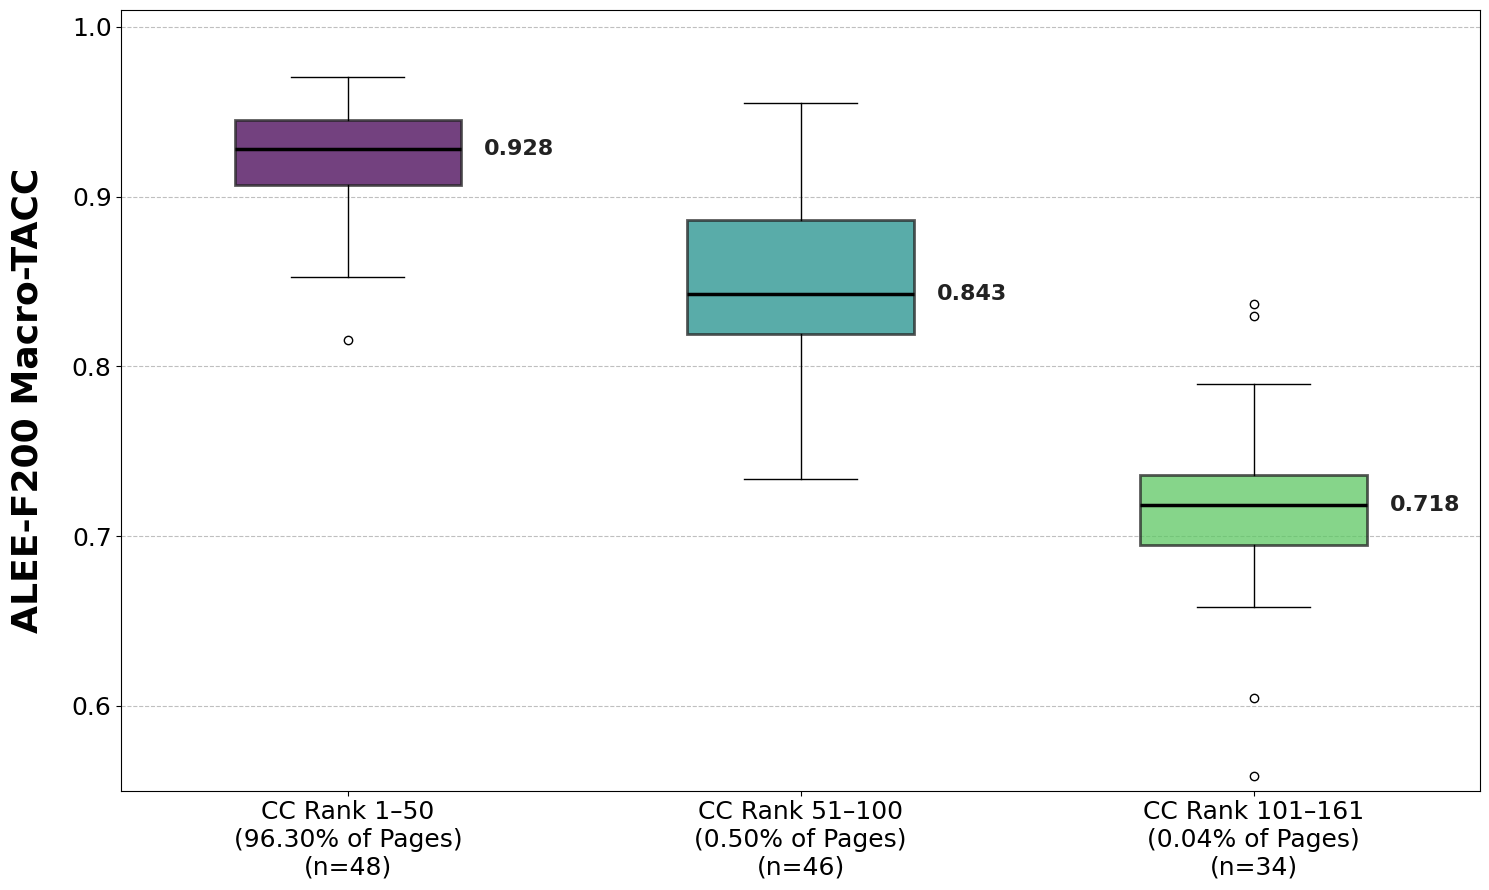

/tmp/ipykernel_18426/2077315044.py:137: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(group_data, labels=final_labels, patch_artist=True, widths=0.5)


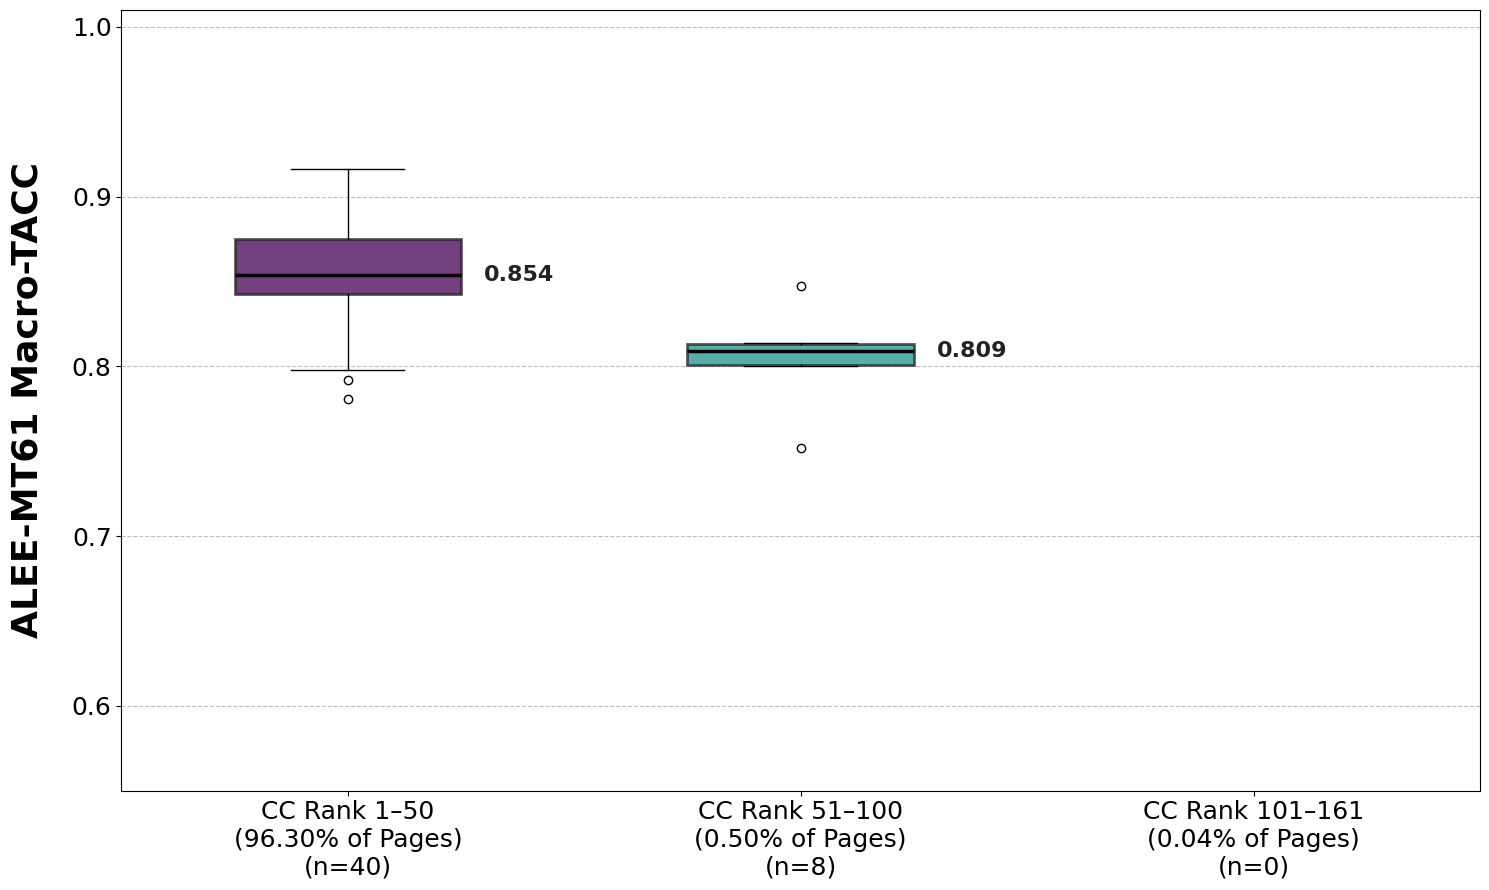

  [ALEE-BQ275 Macro-TACC] dropped (not in CC sets): ['abl', 'agr', 'aiq', 'ami', 'ane', 'arh', 'arn', 'ayz', 'azm', 'azz', 'bam', 'bas', 'bba', 'bft', 'bhb', 'bho', 'brh', 'brx', 'bsh', 'bsk', 'cak', 'che', 'chv', 'cja', 'cjk', 'ckl', 'crk', 'cux', 'daq', 'dgo', 'dik', 'diq', 'djc', 'dje', 'dtm', 'dts', 'dua', 'enb', 'enl', 'eto', 'ewo', 'fia', 'fuc', 'fuv', 'fvr', 'gax', 'gil', 'gkp', 'gom', 'guc', 'gug', 'guz', 'gxx', 'heh', 'hne', 'hve', 'ijc', 'ilo', 'irk', 'jmc', 'jnj', 'kaa', 'kac', 'kai', 'kam', 'kea', 'kek', 'khq', 'khw', 'kls', 'kmb', 'knc', 'knw', 'krt', 'kru', 'ksf', 'ktu', 'kuj', 'kwy', 'kxp', 'led', 'lgg', 'lij', 'lim', 'lir', 'loa', 'loh', 'luo', 'maf', 'mai', 'mam', 'mas', 'mey', 'mie', 'min', 'miq', 'mos', 'mtq', 'mzl', 'naq', 'nhe', 'nlv', 'nus', 'pbs', 'pcm', 'quc', 'rob', 'sat', 'sba', 'scn', 'sgc', 'shn', 'sif', 'skr', 'sme', 'sro', 'szl', 'taq', 'tda', 'toc', 'tpi', 'tpl', 'tsg', 'tsz', 'tui', 'tzh', 'tzm', 'umb', 'vmw', 'wlv', 'xuu', 'ydg', 'yua', 'zai', 'zne']


/tmp/ipykernel_18426/2077315044.py:137: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(group_data, labels=final_labels, patch_artist=True, widths=0.5)


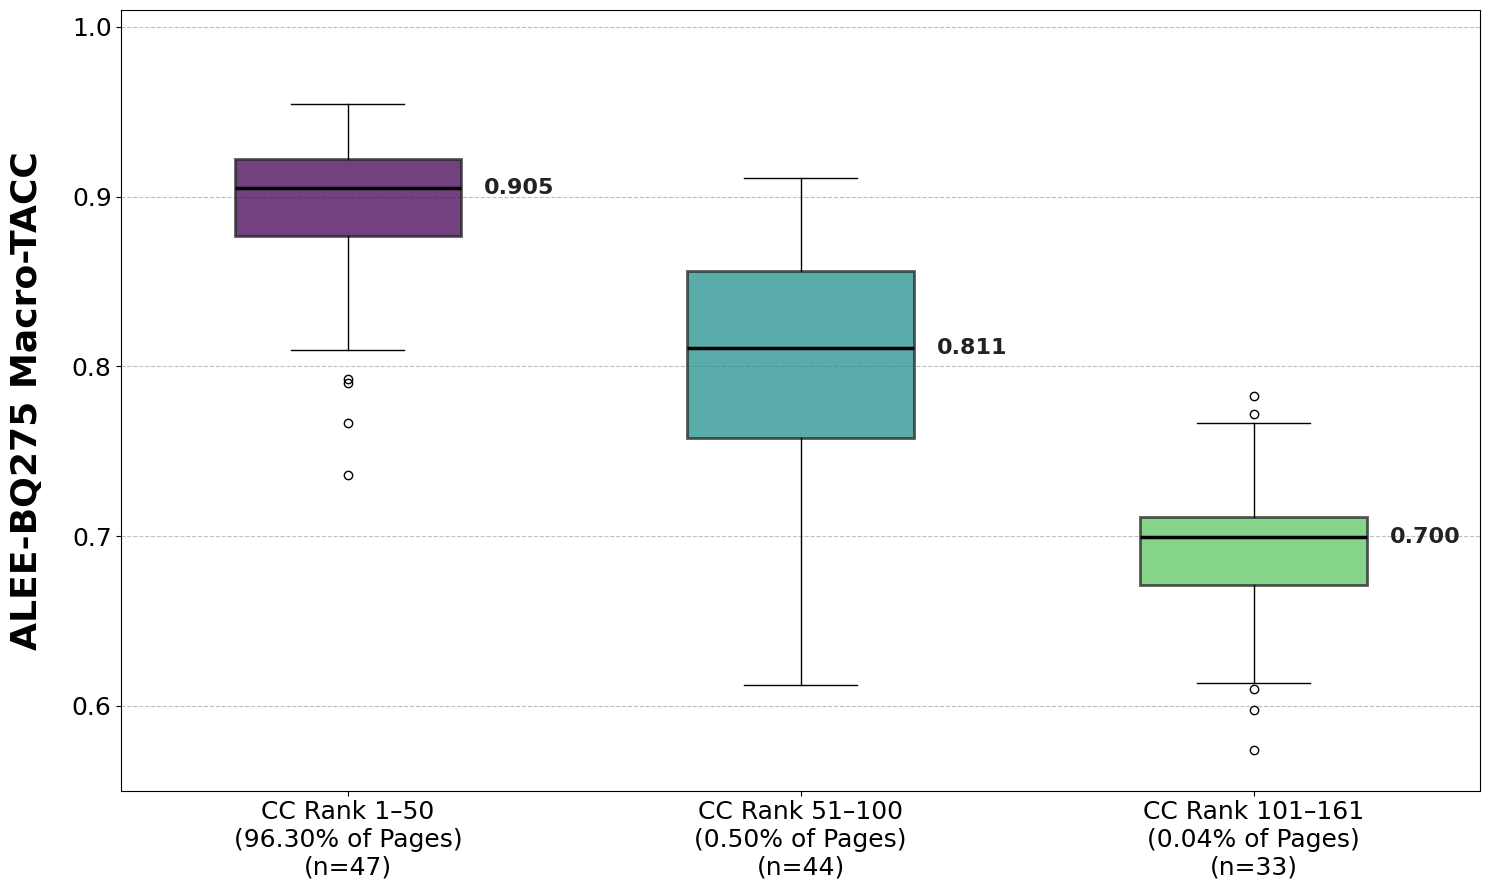

In [23]:
# PLOT: Macro-TACC by Common Crawl rank tier (ranks 1-50 / 51-100 / 101-161),
# one box-plot figure per dataset. Tests whether a language's Common Crawl frequency
# tier predicts TACC. The CC_* sets below define the tier membership.

# --- Common Crawl CC-MAIN-2026-08 rank tiers (excluding eng) ---
CC_TOP_50 = {
    "rus", "deu", "jpn", "zho", "spa", "fra", "por", "ita", "pol", "nld",
    "tur", "ces", "vie", "ind", "fas", "kor", "ukr", "swe", "ara", "ell",
    "hun", "dan", "ron", "slk", "tha", "fin", "nor", "bul", "srp", "heb",
    "hin", "cat", "hrv", "lit", "est", "slv", "ben", "lat", "lav", "msa",
    "aze", "bos", "nep", "sqi", "tam", "kat", "eus", "isl", "kaz",
}  # ranks 2-50, ~96.3% of CC pages (when including English)
CC_51_100 = {
    "glg", "mkd", "hye", "urd", "mar", "mal", "uzb", "tel", "kan", "mya",
    "bel", "mon", "nno", "swa", "guj", "kir", "epo", "cym", "sin", "tgl",
    "khm", "tat", "pan", "afr", "ori", "kur", "gle", "tgk", "mlg", "san",
    "som", "fao", "pus", "lao", "amh", "tuk", "oci", "bak", "ltz", "hau",
    "bre", "jav", "asm", "mlt", "cos", "hat", "fry", "snd", "div", "ceb",
}  # ranks 51-100, ~0.5% of CC pages
CC_101_161 = {
    "kin", "yid", "gla", "sun", "war", "uig", "sag", "yor", "roh", "bod",
    "ibo", "mri", "zul", "kal", "que", "grn", "orm", "xho", "haw", "sna",
    "vol", "abk", "bih", "hmn", "ina", "nya", "sco", "smo", "tir", "glv",
    "sot", "ile", "lin", "aka", "iku", "kha", "lug", "syr", "tsn", "wol",
    "bis", "mfe", "aar", "aym", "crs", "dzo", "fij", "ipk", "nso", "run",
    "ton", "tso", "zha", "chr", "got", "kas", "lif", "nau", "ssw", "sux",
    "ven",
}  # ranks 101-161, ~0.04% of CC pages
CC_ALL = CC_TOP_50 | CC_51_100 | CC_101_161

# FLORES (and a few other) iso3 codes mapped to their Common Crawl macrolanguage
# / spelling equivalent, so script/dialect variants aren't silently dropped.
# Only includes cases with a real CC equivalent; languages genuinely absent
# from CC are intentionally left to drop.
FLORES_TO_CC_ISO = {
    # Arabic varieties -> ara
    'arb': 'ara', 'acm': 'ara', 'acq': 'ara', 'aeb': 'ara', 'ajp': 'ara',
    'apc': 'ara', 'ars': 'ara', 'ary': 'ara', 'arz': 'ara',
    # Persian varieties -> fas
    'pes': 'fas', 'prs': 'fas',
    # Azerbaijani -> aze
    'azj': 'aze', 'azb': 'aze',
    # Chinese varieties -> zho
    'cmn': 'zho', 'yue': 'zho', 'wuu': 'zho',
    # Quechua varieties -> que
    'quy': 'que', 'quh': 'que', 'quz': 'que',
    # Kurdish varieties -> kur
    'ckb': 'kur', 'kmr': 'kur',
    # Single-code macrolanguage / spelling normalizations
    'lvs': 'lav',   # Standard Latvian   -> Latvian
    'nob': 'nor',   # Norwegian Bokmål   -> Norwegian
    'zsm': 'msa',   # Standard Malay     -> Malay
    'swh': 'swa',   # Swahili            -> Swahili (macro)
    'als': 'sqi',   # Tosk Albanian      -> Albanian
    'khk': 'mon',   # Halh Mongolian     -> Mongolian
    'gaz': 'orm',   # West Central Oromo -> Oromo
    'ory': 'ori',   # Odia               -> Oriya (CC spelling)
    'npi': 'nep',   # Nepali             -> Nepali (macro)
    'plt': 'mlg',   # Plateau Malagasy   -> Malagasy
    'uzn': 'uzb',   # Northern Uzbek     -> Uzbek
    'pbt': 'pus',   # Southern Pashto    -> Pashto
    'ekk': 'est',   # Standard Estonian  -> Estonian
    'ayr': 'aym',   # Central Aymara     -> Aymara
    'twi': 'aka',   # Twi                -> Akan
    'ydd': 'yid',   # Eastern Yiddish    -> Yiddish
}

# --- iso3 extraction per dataset ---
# F200 / BQ275 are keyed by FLORES codes (e.g. deu_Latn) -> iso3 is the prefix.
# MT61 is keyed by WMT codes (e.g. de_DE) -> map through wmt_to_flores first,
# which yields the same FLORES prefix (de_DE -> deu_Latn -> deu).
def iso3_from_flores(code):
    return code.split('_')[0]

def iso3_from_wmt(code):
    flores = wmt_to_flores.get(code)
    return flores.split('_')[0] if flores else None

# (dataset frame, lang column, iso3 function, y-label, save filename)
datasets = [
    (perf_flores_all, 'flores_lang', iso3_from_flores,
     'ALEE-F200 Macro-TACC', 'cc_rank_tier_boxplot_f200.png'),
    (perf_wmt_all, 'wmt_lang', iso3_from_wmt,
     'ALEE-MT61 Macro-TACC', 'cc_rank_tier_boxplot_mt61.png'),
    (perf_bouquet_all, 'flores_lang', iso3_from_flores,
     'ALEE-BQ275 Macro-TACC', 'cc_rank_tier_boxplot_bq275.png'),
]

labels = [
    "CC Rank 1–50\n(96.30% of Pages)",
    "CC Rank 51–100\n(0.50% of Pages)",
    "CC Rank 101–161\n(0.04% of Pages)",
]
group_colors = ['#440154', '#21908d', '#5dc863']   # viridis dark -> light

Y_LIMITS = (0.55, 1.01)   # shared across all three plots for comparability

for perf_df, lang_col, iso3_fn, ylabel, fname in datasets:
    # --- Data preparation ---
    df = perf_df.copy()
    df['iso3'] = df[lang_col].apply(iso3_fn)
    df = df[df['iso3'].notna() & (df['iso3'] != 'eng')]

    # Map each language to its CC code, then to a tier
    df['cc_iso3'] = df['iso3'].apply(lambda x: FLORES_TO_CC_ISO.get(x, x))
    df['cc_tier'] = df['cc_iso3'].apply(
        lambda c: 0 if c in CC_TOP_50 else 1 if c in CC_51_100 else 2 if c in CC_101_161 else None
    )

    # Diagnostic: languages with no CC tier (genuinely not in CC)
    unmatched = sorted(set(df[df['cc_tier'].isna()]['iso3']))
    if unmatched:
        print(f"  [{ylabel}] dropped (not in CC sets): {unmatched}")

    df = df.dropna(subset=['cc_tier'])

    # Average TACC across variants sharing a CC language -> one point per CC language
    df = (df.groupby('cc_iso3', as_index=False)
            .agg(tacc=('tacc', 'mean'), cc_tier=('cc_tier', 'first')))
    df['cc_tier'] = df['cc_tier'].astype(int)

    group_data = [
        df[df['cc_tier'] == 0]['tacc'].values,
        df[df['cc_tier'] == 1]['tacc'].values,
        df[df['cc_tier'] == 2]['tacc'].values,
    ]
    n_counts = [len(d) for d in group_data]
    final_labels = [f"{lbl}\n(n={n})" for lbl, n in zip(labels, n_counts)]

    # --- Visualization ---
    fig, ax = plt.subplots(figsize=(15, 9))
    bp = ax.boxplot(group_data, labels=final_labels, patch_artist=True, widths=0.5)

    for patch, color in zip(bp['boxes'], group_colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.75)
        patch.set_edgecolor('#222222')
        patch.set_linewidth(2.0)
    for median in bp['medians']:
        median.set_color('#000000')
        median.set_linewidth(2.5)

    # Median value label beside each box
    for i, d in enumerate(group_data):
        if len(d) == 0:
            continue
        med = np.median(d)
        ax.text(i + 1 + 0.30, med, f'{med:.3f}',
                va='center', ha='left', fontsize=16, fontweight='bold', color='#222222')

    # --- Axes and grid ---
    ax.set_ylabel(ylabel, fontsize=26, fontweight='bold', labelpad=20)
    ax.set_ylim(*Y_LIMITS)
    ax.tick_params(axis='x', labelsize=18)
    ax.tick_params(axis='y', labelsize=18)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5, color='gray')
    ax.set_axisbelow(True)

    # --- Output ---
    plt.tight_layout()
    plt.savefig(f'{figures_dir}/{fname}', bbox_inches='tight', dpi=300)
    plt.show()
    plt.close()

# GTE pretraining / contrastive analysis

Same training-data question, but for one specific model
(`Alibaba_NLP_gte_multilingual_base`), where both pretraining and post-training data
volumes are known per language.

Compares per-language TACC against (a) unsupervised pretraining tokens and
(b) CC-News contrastive post-training pairs, across all three datasets.


In [24]:
# ============================================================
# GTE MULTILINGUAL BASE: PRE-TRAINING vs POST-TRAINING DATA
# ============================================================
# Side-by-side correlation of language performance with
# (a) unsupervised pre-training tokens and (b) cc-news post-training pairs.
# Only includes languages present in the respective data source.
# Assumes df_wmt, df_flores, wmt_to_flores, flores_to_wmt,
# lang_names, get_metrics are defined.

# --- Cell GTE1: Data definitions ---

GTE_MODEL = "Alibaba_NLP_gte_multilingual_base"

# Unsupervised pre-training data: lang_code -> (language_name, tokens in millions)
pretraining_data = {
    "af": ("Afrikaans", 1489.19), "ar": ("Arabic", 14549.36),
    "az": ("Azerbaijani", 688.72), "be": ("Belarusian", 1090.61),
    "bg": ("Bulgarian", 1454.57), "bn": ("Bengali", 1291.58),
    "ca": ("Catalan", 1294.05), "ceb": ("Cebuano", 633.06),
    "cs": ("Czech", 1465.00), "cy": ("Welsh", 582.49),
    "da": ("Danish", 1030.30), "de": ("German", 18097.31),
    "el": ("Greek", 874.87), "en": ("English", 187110.31),
    "es": ("Spanish", 148713.06), "et": ("Estonian", 1111.31),
    "eu": ("Basque", 787.46), "fa": ("Persian", 1203.16),
    "fi": ("Finnish", 949.88), "fr": ("French", 136785.00),
    "gl": ("Galician", 772.47), "gu": ("Gujarati", 973.27),
    "he": ("Hebrew", 1842.74), "hi": ("Hindi", 1032.67),
    "hr": ("Croatian", 480.19), "ht": ("Haitian", 0.03),
    "hu": ("Hungarian", 1341.23), "hy": ("Armenian", 805.98),
    "id": ("Indonesian", 25564.33), "is": ("Icelandic", 987.89),
    "it": ("Italian", 11068.23), "ja": ("Japanese", 135684.28),
    "jv": ("Javanese", 0.62), "ka": ("Georgian", 834.90),
    "kk": ("Kazakh", 1020.27), "km": ("Khmer", 746.15),
    "kn": ("Kannada", 919.83), "ko": ("Korean", 22865.85),
    "ky": ("Kyrgyz", 500.40), "lo": ("Lao", 2.43),
    "lt": ("Lithuanian", 1824.46), "lv": ("Latvian", 1823.43),
    "mk": ("Macedonian", 735.46), "ml": ("Malayalam", 778.66),
    "mn": ("Mongolian", 958.83), "mr": ("Marathi", 861.05),
    "ms": ("Malay", 96.37), "my": ("Burmese", 902.46),
    "ne": ("Nepali", 657.65), "nl": ("Dutch", 5137.98),
    "no": ("Norwegian", 992.51), "pa": ("Punjabi", 726.41),
    "pl": ("Polish", 2949.88), "pt": ("Portuguese", 49594.59),
    "qu": ("Quechua", 0.07), "ro": ("Romanian", 2215.05),
    "ru": ("Russian", 93966.28), "si": ("Sinhala", 878.65),
    "sk": ("Slovak", 884.38), "sl": ("Slovenian", 1100.81),
    "so": ("Somali", 0.82), "sq": ("Albanian", 700.78),
    "sr": ("Serbian", 1139.38), "sv": ("Swedish", 840.00),
    "sw": ("Swahili", 31.58), "ta": ("Tamil", 926.84),
    "te": ("Telugu", 857.91), "th": ("Thai", 12782.08),
    "tl": ("Filipino", 275.16), "tr": ("Turkish", 1065.05),
    "uk": ("Ukrainian", 893.70), "ur": ("Urdu", 1051.83),
    "vi": ("Vietnamese", 67850.87), "yo": ("Yoruba", 0.04),
    "zh_simp": ("Chinese (Simplified)", 43727.30),
    "zh_trad": ("Chinese (Traditional)", 73.39),
}

# CC-News post-training pairs (in millions)
posttraining_data = {
    "ar": 20.407, "az": 0.401, "be": 0.039, "bg": 3.005,
    "bn": 0.463, "ca": 0.909, "cs": 1.834, "da": 1.090,
    "de": 39.715, "el": 7.170, "en": 0.615, "es": 55.201,
    "et": 0.950, "eu": 0.051, "fa": 4.839, "fi": 1.532,
    "fr": 21.242, "fy": 0.044, "gl": 0.114, "gu": 0.061,
    "he": 0.397, "hi": 14.253, "hr": 1.268, "hu": 2.668,
    "hy": 0.125, "id": 6.048, "is": 0.100, "it": 27.827,
    "ja": 4.139, "ka": 0.074, "kn": 0.192, "ko": 8.605,
    "ky": 0.061, "la": 0.035, "lb": 0.048, "lt": 0.321,
    "lv": 0.438, "mk": 0.173, "ml": 0.408, "mr": 0.278,
    "my": 0.045, "nl": 6.700, "nn": 0.162, "no": 1.978,
    "or": 0.038, "pa": 0.036, "pl": 3.530, "pt": 12.611,
    "ro": 6.678, "ru": 39.451, "sh": 0.220, "sk": 1.093,
    "sl": 1.046, "sq": 0.282, "sr": 0.910, "sv": 3.361,
    "sw": 0.059, "ta": 2.125, "te": 0.355, "tg": 0.038,
    "th": 0.124, "tl": 0.055, "tr": 23.840, "uk": 5.021,
    "ur": 1.625, "vi": 4.375,
}

# FLORES ISO 639-3 -> ISO 639-1 (reuse from earlier, subset relevant here)
_flores_to_iso = {
    'afr': 'af', 'arb': 'ar', 'azj': 'az', 'azb': 'az',
    'bel': 'be', 'bul': 'bg', 'ben': 'bn', 'cat': 'ca',
    'ceb': 'ceb', 'ces': 'cs', 'cym': 'cy', 'dan': 'da',
    'deu': 'de', 'ell': 'el', 'spa': 'es', 'est': 'et',
    'eus': 'eu', 'pes': 'fa', 'prs': 'fa', 'fin': 'fi',
    'fra': 'fr', 'glg': 'gl', 'guj': 'gu', 'heb': 'he',
    'hin': 'hi', 'hrv': 'hr', 'hat': 'ht', 'hun': 'hu',
    'hye': 'hy', 'ind': 'id', 'isl': 'is', 'ita': 'it',
    'jpn': 'ja', 'jav': 'jv', 'kat': 'ka', 'kaz': 'kk',
    'khm': 'km', 'kan': 'kn', 'kor': 'ko', 'kir': 'ky',
    'lao': 'lo', 'lit': 'lt', 'lvs': 'lv', 'mkd': 'mk',
    'mal': 'ml', 'khk': 'mn', 'mar': 'mr', 'zsm': 'ms',
    'mya': 'my', 'npi': 'ne', 'nld': 'nl', 'nob': 'no',
    'nno': 'no', 'pan': 'pa', 'pol': 'pl', 'por': 'pt',
    'ron': 'ro', 'rus': 'ru', 'sin': 'si', 'slk': 'sk',
    'slv': 'sl', 'som': 'so', 'sqi': 'sq', 'als': 'sq',
    'srp': 'sr', 'swe': 'sv', 'swh': 'sw', 'tam': 'ta',
    'tel': 'te', 'tha': 'th', 'tgl': 'tl', 'tur': 'tr',
    'ukr': 'uk', 'urd': 'ur', 'vie': 'vi', 'yor': 'yo',
    'zho_Hans': 'zh_simp', 'zho_Hant': 'zh_trad',
}

# WMT lang code -> ISO 639-1
_wmt_to_iso = {
    'ar_EG': 'ar', 'bg_BG': 'bg', 'bn_IN': 'bn', 'ca_ES': 'ca',
    'cs_CZ': 'cs', 'da_DK': 'da', 'de_DE': 'de', 'el_GR': 'el',
    'es_MX': 'es', 'et_EE': 'et', 'fa_IR': 'fa', 'fi_FI': 'fi',
    'fil_PH': 'tl', 'fr_FR': 'fr', 'gu_IN': 'gu', 'he_IL': 'he',
    'hi_IN': 'hi', 'hr_HR': 'hr', 'hu_HU': 'hu', 'id_ID': 'id',
    'is_IS': 'is', 'it_IT': 'it', 'ja_JP': 'ja', 'kn_IN': 'kn',
    'ko_KR': 'ko', 'lt_LT': 'lt', 'lv_LV': 'lv', 'ml_IN': 'ml',
    'mr_IN': 'mr', 'nl_NL': 'nl', 'no_NO': 'no', 'pa_IN': 'pa',
    'pl_PL': 'pl', 'pt_BR': 'pt', 'ro_RO': 'ro', 'ru_RU': 'ru',
    'sk_SK': 'sk', 'sl_SI': 'sl', 'sr_RS': 'sr', 'sv_SE': 'sv',
    'sw_KE': 'sw', 'ta_IN': 'ta', 'te_IN': 'te', 'th_TH': 'th',
    'tr_TR': 'tr', 'uk_UA': 'uk', 'ur_PK': 'ur', 'vi_VN': 'vi',
    'zh_CN': 'zh_simp', 'zh_TW': 'zh_trad',
}

In [25]:
# Compute per-language Macro-TACC for the GTE model only, across F200 / MT61 / BQ275.
# --- Cell GTE2: Compute per-language performance for GTE model ---

# FLORES
df_gte_flores = df_flores[df_flores['model'] == GTE_MODEL].copy()
df_gte_flores['flores_lang'] = df_gte_flores['lang_pair'].str.replace('eng_Latn-', '')
df_gte_flores['iso'] = df_gte_flores['flores_lang'].apply(
    lambda x: _flores_to_iso.get(x.split('_')[0]) if x not in ('zho_Hans', 'zho_Hant')
    else _flores_to_iso.get(x)
)

perf_gte_flores = macro_tacc(df_gte_flores, ['flores_lang', 'iso'])

# WMT
df_gte_wmt = df_wmt[df_wmt['model'] == GTE_MODEL].copy()
df_gte_wmt['lang'] = df_gte_wmt['lang_pair'].str.replace('en_EN-', '')
df_gte_wmt['iso'] = df_gte_wmt['lang'].map(_wmt_to_iso)

perf_gte_wmt = macro_tacc(df_gte_wmt, ['lang', 'iso'])

print(f"GTE ALEE-F200 languages: {len(perf_gte_flores)}")
print(f"GTE ALEE-MT61 languages: {len(perf_gte_wmt)}")

# BOUQUET (same FLORES-style codes as F200)
df_gte_bouquet = df_bouquet[df_bouquet['model'] == GTE_MODEL].copy()
df_gte_bouquet['flores_lang'] = df_gte_bouquet['lang_pair'].str.replace('eng_Latn-', '')
df_gte_bouquet['iso'] = df_gte_bouquet['flores_lang'].apply(
    lambda x: _flores_to_iso.get(x.split('_')[0]) if x not in ('zho_Hans', 'zho_Hant')
    else _flores_to_iso.get(x)
)

perf_gte_bouquet = macro_tacc(df_gte_bouquet, ['flores_lang', 'iso'])

print(f"GTE ALEE-BQ275 languages: {len(perf_gte_bouquet)}")

GTE ALEE-F200 languages: 78
GTE ALEE-MT61 languages: 49
GTE ALEE-BQ275 languages: 76


In [26]:
# Attach pre-training token and post-training pair counts per language, then build the
# *_pre / *_post filtered frames (one per dataset) consumed by all GTE plots below.
def add_data_columns(perf_df):
    """Add pre-training and post-training token columns."""
    perf_df = perf_df.copy()
    perf_df['pre_tokens_m'] = perf_df['iso'].apply(
        lambda x: pretraining_data[x][1] if x in pretraining_data else None
    )
    perf_df['post_pairs_m'] = perf_df['iso'].apply(
        lambda x: posttraining_data.get(x)
    )
    perf_df['lang_name'] = perf_df['iso'].apply(
        lambda x: pretraining_data[x][0] if x in pretraining_data else x
    )
    return perf_df

perf_gte_flores = add_data_columns(perf_gte_flores)
perf_gte_wmt = add_data_columns(perf_gte_wmt)

# Filter to only languages present in pre-training data
flores_pre = perf_gte_flores.dropna(subset=['pre_tokens_m']).copy()
flores_pre['log_pre'] = np.log10(flores_pre['pre_tokens_m'])

wmt_pre = perf_gte_wmt.dropna(subset=['pre_tokens_m']).copy()
wmt_pre['log_pre'] = np.log10(wmt_pre['pre_tokens_m'])

# Filter to only languages present in post-training data
flores_post = perf_gte_flores.dropna(subset=['post_pairs_m']).copy()
flores_post['log_post'] = np.log10(flores_post['post_pairs_m'])

wmt_post = perf_gte_wmt.dropna(subset=['post_pairs_m']).copy()
wmt_post['log_post'] = np.log10(wmt_post['post_pairs_m'])

# BOUQUET pre/post frames (built like F200)
perf_gte_bouquet = add_data_columns(perf_gte_bouquet)

bouquet_pre = perf_gte_bouquet.dropna(subset=['pre_tokens_m']).copy()
bouquet_pre['log_pre'] = np.log10(bouquet_pre['pre_tokens_m'])

bouquet_post = perf_gte_bouquet.dropna(subset=['post_pairs_m']).copy()
bouquet_post['log_post'] = np.log10(bouquet_post['post_pairs_m'])

print(f"ALEE-F200 — pre-training langs: {len(flores_pre)}, post-training langs: {len(flores_post)}")
print(f"ALEE-MT61 — pre-training langs: {len(wmt_pre)}, post-training langs: {len(wmt_post)}")
print(f"ALEE-BQ275 — pre-training langs: {len(bouquet_pre)}, post-training langs: {len(bouquet_post)}")

ALEE-F200 — pre-training langs: 78, post-training langs: 62
ALEE-MT61 — pre-training langs: 49, post-training langs: 47
ALEE-BQ275 — pre-training langs: 76, post-training langs: 62


In [27]:
# PLOT: 2x3 scatter grid of Macro-TACC vs training data for the GTE model.
# Columns = datasets (F200 / MT61 / BQ275); rows = pre-training (top) / post-training.
fig, axes = plt.subplots(2, 3, figsize=(24, 14))

# Columns: F200, MT61, BQ275.  Rows: pre-training (top), post-training (bottom).
panels = [
    # top row — pre-training
    (axes[0, 0], flores_pre,  'log_pre',  'ALEE-F200 — Pre-training',  '#1976d2', 'log₁₀(pre-training tokens in M)'),
    (axes[0, 1], wmt_pre,     'log_pre',  'ALEE-MT61 — Pre-training',  '#1976d2', 'log₁₀(pre-training tokens in M)'),
    (axes[0, 2], bouquet_pre, 'log_pre',  'ALEE-BQ275 — Pre-training', '#1976d2', 'log₁₀(pre-training tokens in M)'),
    # bottom row — post-training
    (axes[1, 0], flores_post,  'log_post', 'ALEE-F200 — Post-training',  '#d32f2f', 'log₁₀(post-training pairs in M)'),
    (axes[1, 1], wmt_post,     'log_post', 'ALEE-MT61 — Post-training',  '#d32f2f', 'log₁₀(post-training pairs in M)'),
    (axes[1, 2], bouquet_post, 'log_post', 'ALEE-BQ275 — Post-training', '#d32f2f', 'log₁₀(post-training pairs in M)'),
]

for ax, data, xcol, title, color, xlabel in panels:
    ax.scatter(data[xcol], data['tacc'], alpha=0.6, s=45, c=color)

    for _, row in data.iterrows():
        ax.annotate(row['lang_name'], (row[xcol], row['tacc']),
                    fontsize=5.5, alpha=0.55, ha='left', va='bottom')

    r, p = stats.pearsonr(data[xcol], data['tacc'])
    rho, _ = stats.spearmanr(data[xcol], data['tacc'])
    z = np.polyfit(data[xcol], data['tacc'], 1)
    x_line = np.linspace(data[xcol].min(), data[xcol].max(), 100)
    ax.plot(x_line, np.polyval(z, x_line), 'k--', alpha=0.4)

    ax.set_xlabel(xlabel, fontsize=14)
    ax.set_ylabel('Macro-TACC', fontsize=14)
    ax.set_title(f'{title} (n={len(data)})\nr={r:.3f} (p={p:.4f}), ρ={rho:.3f}', fontsize=14)

plt.suptitle(f'{GTE_MODEL}: Macro-TACC vs training data', fontsize=16, y=1.01)
plt.tight_layout()
plt.savefig(f'{figures_dir}/gte_combined_2x3--cell70.pdf', bbox_inches='tight')
plt.close()

In [28]:
# PLOT: same 2x3 grid as the earlier GTE figure, but with adjustText label thinning
# in dense regions (select_labels drops a fraction of crowded labels). Variant figure.

def select_labels(data, xcol, drop_frac=0.0, dense_lo=0.25, dense_hi=0.75,
                  protect_below=0.8, seed=0):
    """Drop drop_frac of labels inside the dense x-band; keep all others.
    Never drop a label whose tacc is below protect_below."""
    if drop_frac <= 0:
        return data
    lo, hi = data[xcol].quantile(dense_lo), data[xcol].quantile(dense_hi)
    in_dense = (data[xcol] >= lo) & (data[xcol] <= hi)
    keep = ~in_dense  # keep everything outside the dense band
    keep |= data['tacc'] < protect_below  # always keep low-tacc points
    droppable = data.index[in_dense & (data['tacc'] >= protect_below)]
    n_keep = round(len(droppable) * (1 - drop_frac))
    kept = np.random.default_rng(seed).choice(droppable, size=n_keep, replace=False)
    keep.loc[kept] = True
    return data[keep]

fig, axes = plt.subplots(2, 3, figsize=(24, 14))
# Columns: F200, MT61, BQ275.  Rows: pre-training (top), post-training (bottom).
# Last tuple field is drop_frac (label thinning in the dense band).
panels = [
    # top row — pre-training
    (axes[0, 0], flores_pre,  'log_pre',  'ALEE-F200 — Pre-training',  '#1976d2', 'log₁₀(pre-training tokens in M)', 7, 0.65),
    (axes[0, 1], wmt_pre,     'log_pre',  'ALEE-MT61 — Pre-training',  '#1976d2', 'log₁₀(pre-training tokens in M)', 9.5, 0.0),
    (axes[0, 2], bouquet_pre, 'log_pre',  'ALEE-BQ275 — Pre-training', '#1976d2', 'log₁₀(pre-training tokens in M)', 7, 0.65),
    # bottom row — post-training
    (axes[1, 0], flores_post,  'log_post', 'ALEE-F200 — Post-training',  '#d32f2f', 'log₁₀(post-training pairs in M)', 9.5, 0.0),
    (axes[1, 1], wmt_post,     'log_post', 'ALEE-MT61 — Post-training',  '#d32f2f', 'log₁₀(post-training pairs in M)', 9.5, 0.0),
    (axes[1, 2], bouquet_post, 'log_post', 'ALEE-BQ275 — Post-training', '#d32f2f', 'log₁₀(post-training pairs in M)', 9.5, 0.0),
]
for ax, data, xcol, title, color, xlabel, label_size, drop_frac in panels:
    ax.scatter(data[xcol], data['tacc'], alpha=0.6, s=45, c=color)
    labeled = select_labels(data, xcol, drop_frac=drop_frac)
    texts = [
        ax.text(row[xcol], row['tacc'], row['lang_name'],
                fontsize=label_size, alpha=0.7)
        for _, row in labeled.iterrows()
    ]
    adjust_text(texts, ax=ax,
                arrowprops=dict(arrowstyle='-', color='gray', lw=0.4, alpha=0.5))
    r, p = stats.pearsonr(data[xcol], data['tacc'])
    rho, _ = stats.spearmanr(data[xcol], data['tacc'])
    z = np.polyfit(data[xcol], data['tacc'], 1)
    x_line = np.linspace(data[xcol].min(), data[xcol].max(), 100)
    ax.plot(x_line, np.polyval(z, x_line), 'k--', alpha=0.4)
    ax.set_xlabel(xlabel, fontsize=22)
    if ax in (axes[0, 0], axes[1, 0]):
        ax.set_ylabel('Macro-TACC', fontsize=20, fontweight='bold')
    else:
        ax.set_ylabel('')
    ax.set_title(f'{title} (n={len(data)})\nr={r:.3f} (p={p:.4f}), ρ={rho:.3f}',
                 fontsize=20, fontweight='bold')
    ax.tick_params(axis='both', labelsize=16)
plt.tight_layout()
plt.savefig(f'{figures_dir}/gte_combined_2x3--cell70.pdf', bbox_inches='tight')
plt.close()

In [29]:
# Print the correlation summary table: Pearson r, p-value and Spearman rho per dataset
# and per training stage (pre / post).
# --- Cell GTE7: Correlation summary ---

print(f"{'Dataset':<10} {'Stage':<15} {'n_langs':>7} {'Pearson r':>10} {'p-value':>10} {'Spearman ρ':>11}")
print("-" * 65)

for label, data, xcol in [
    ('ALEE-F200', flores_pre, 'log_pre'), ('ALEE-F200', flores_post, 'log_post'),
    ('ALEE-MT61', wmt_pre, 'log_pre'), ('ALEE-MT61', wmt_post, 'log_post'),
    ('ALEE-BQ275', bouquet_pre, 'log_pre'), ('ALEE-BQ275', bouquet_post, 'log_post'),
]:
    stage = 'Pre-training' if 'pre' in xcol else 'Post-training'
    r, p = stats.pearsonr(data[xcol], data['tacc'])
    rho, _ = stats.spearmanr(data[xcol], data['tacc'])
    print(f"{label:<10} {stage:<15} {len(data):>7} {r:>10.3f} {p:>10.4f} {rho:>11.3f}")

Dataset    Stage           n_langs  Pearson r    p-value  Spearman ρ
-----------------------------------------------------------------
ALEE-F200  Pre-training         78      0.593     0.0000       0.554
ALEE-F200  Post-training        62      0.488     0.0001       0.681
ALEE-MT61  Pre-training         49      0.364     0.0100       0.340
ALEE-MT61  Post-training        47      0.644     0.0000       0.638
ALEE-BQ275 Pre-training         76      0.501     0.0000       0.548
ALEE-BQ275 Post-training        62      0.341     0.0067       0.619


# Single language / language-family analysis tool (Romansh case study)

A reusable drill-down tool. Set `DATASET` and `LANG_CODES` and the cells below produce
per-model, per-augmentation, and per-variant TACC tables and plots for any language or
group of related varieties. Romansh (six `rm_*` varieties) is the worked example.


In [30]:
# Tool step 1: list the available language codes for the selected DATASET, with a
# substring search box. Edit DATASET ("wmt" / "flores" / "bouquet") at the top.
DATASET = "wmt"  # <-- change to "flores", "wmt", or "bouquet"

if DATASET == "wmt":
    _df = df_wmt.copy()
    _eng_prefix = "en_EN-"
elif DATASET == "flores":
    _df = df_flores.copy()
    _eng_prefix = "eng_Latn-"
elif DATASET == "bouquet":
    _df = df_bouquet.copy()
    _eng_prefix = "eng_Latn-"
else:
    raise ValueError(f"Unknown dataset: {DATASET}")

# Extract language codes and show unique values
_all_langs = sorted(_df['lang_pair'].str.replace(_eng_prefix, '').unique())
print(f"Dataset: {DATASET}")
print(f"Available language codes ({len(_all_langs)}):\n")

# Print in columns for readability
n_cols = 4
for i in range(0, len(_all_langs), n_cols):
    row = _all_langs[i:i+n_cols]
    print("  ".join(f"{code:<20}" for code in row))

# Helpful: filter for a substring (e.g. Romansh)
print("\n--- Quick search (edit the filter below) ---")
_search = "rm_"  # <-- change to search for specific codes, e.g. "rm", "roh", "rum"
rm_matches = [c for c in _all_langs if _search.lower() in c.lower()]
if rm_matches:
    print(f"Codes containing '{_search}': {rm_matches}")
else:
    print(f"No codes containing '{_search}'")

Dataset: wmt
Available language codes (61):

ar_EG                 ar_SA                 bg_BG                 bn_IN               
ca_ES                 cs_CZ                 da_DK                 de_DE               
el_GR                 en_EN                 es_MX                 et_EE               
fa_IR                 fi_FI                 fr_CA                 fr_FR               
gu_IN                 he_IL                 hi_IN                 hr_HR               
hu_HU                 id_ID                 is_IS                 it_IT               
ja_JP                 kn_IN                 ko_KR                 lt_LT               
lv_LV                 ml_IN                 mr_IN                 nl_NL               
no_NO                 pa_IN                 pl_PL                 pt_BR               
pt_PT                 rm_PU                 rm_RG                 rm_SM               
rm_ST                 rm_SV                 rm_VA                 ro_RO              

In [31]:
# Tool step 2: select and order the target LANG_CODES for the drill-down.
# Set the language code(s) to analyse.
# Single code: LANG_CODES = ["el_GR"]
# Multiple (e.g. Romansh variants): LANG_CODES = ["roh_Latn_rumgr", "roh_Latn_sursilv", ...]
LANG_CODES = ['rm_RG', 'rm_SV', 'rm_VA', 'rm_PU', 'rm_SM', 'rm_ST']

_df_lang = _df.copy()
_df_lang['lang'] = _df_lang['lang_pair'].str.replace(_eng_prefix, '')
_df_lang = _df_lang[_df_lang['lang'].isin(LANG_CODES)]

# 🔹 Enforce original order
_df_lang['lang'] = pd.Categorical(
    _df_lang['lang'],
    categories=LANG_CODES,
    ordered=True
)

if len(_df_lang) == 0:
    print(f"No data found for {LANG_CODES} in {DATASET}!")
    print("Run cell L1 to see available codes.")
else:
    print(f"Dataset: {DATASET}")
    print(f"Language(s): {LANG_CODES}")
    print(f"Rows: {len(_df_lang)}")
    print(f"Models: {_df_lang['model'].nunique()}")
    print(f"Augmentation categories: {sorted(_df_lang['aug_category'].unique())}")

Dataset: wmt
Language(s): ['rm_RG', 'rm_SV', 'rm_VA', 'rm_PU', 'rm_SM', 'rm_ST']
Rows: 165900
Models: 14
Augmentation categories: ['antonym_replacement', 'hypernym_substitution', 'polarity_negation', 'role_swap']


In [32]:
# Tool step 3: overall per-model TACC and per-(model, augmentation) TACC tables for the
# selected languages.
# Overall per model
_results_overall = macro_tacc(_df_lang, ['model']).sort_values('tacc', ascending=False)

print(f"=== Overall results for {LANG_CODES} ({DATASET}) ===")
print(_results_overall.to_string(index=False))

# Per model × augmentation
_results_aug = _df_lang.groupby(['model', 'aug_category']).apply(
    get_metrics, include_groups=False
).reset_index()

print(f"\n=== Per augmentation ===")
for aug in sorted(_results_aug['aug_category'].unique()):
    print(f"\n  {aug}:")
    sub = _results_aug[_results_aug['aug_category'] == aug].sort_values('tacc', ascending=False)
    print(sub[['model', 'tacc']].to_string(index=False))

=== Overall results for ['rm_RG', 'rm_SV', 'rm_VA', 'rm_PU', 'rm_SM', 'rm_ST'] (wmt) ===
                            model     tacc
   multilingual_e5_large_instruct 0.796400
      sentence_transformers_LaBSE 0.793946
            multilingual_e5_large 0.765207
                      BAAI_bge_m3 0.759921
Alibaba_NLP_gte_multilingual_base 0.743838
             multilingual_e5_base 0.730026
       google_embeddinggemma_300m 0.721659
    ibm_granite_embed_107m_multiL 0.714098
    ibm_granite_embed_278m_multiL 0.714061
          nomic_embed_text_v2_moe 0.701846
               jina_embeddings_v3 0.676743
     paraphrase_multiL_mpnet_base 0.670598
    jina_embeddings_v5_text_small 0.659903
     jina_embeddings_v5_text_nano 0.649864

=== Per augmentation ===

  antonym_replacement:
                            model     tacc
   multilingual_e5_large_instruct 0.774202
      sentence_transformers_LaBSE 0.770077
            multilingual_e5_large 0.750825
Alibaba_NLP_gte_multilingual_base 0.741199
 

/tmp/ipykernel_18426/1559903658.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_aug = df.groupby(groupby_cols + ['aug_category']).apply(
/tmp/ipykernel_18426/1559903658.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = per_aug.groupby(groupby_cols)['tacc'].mean().reset_index()


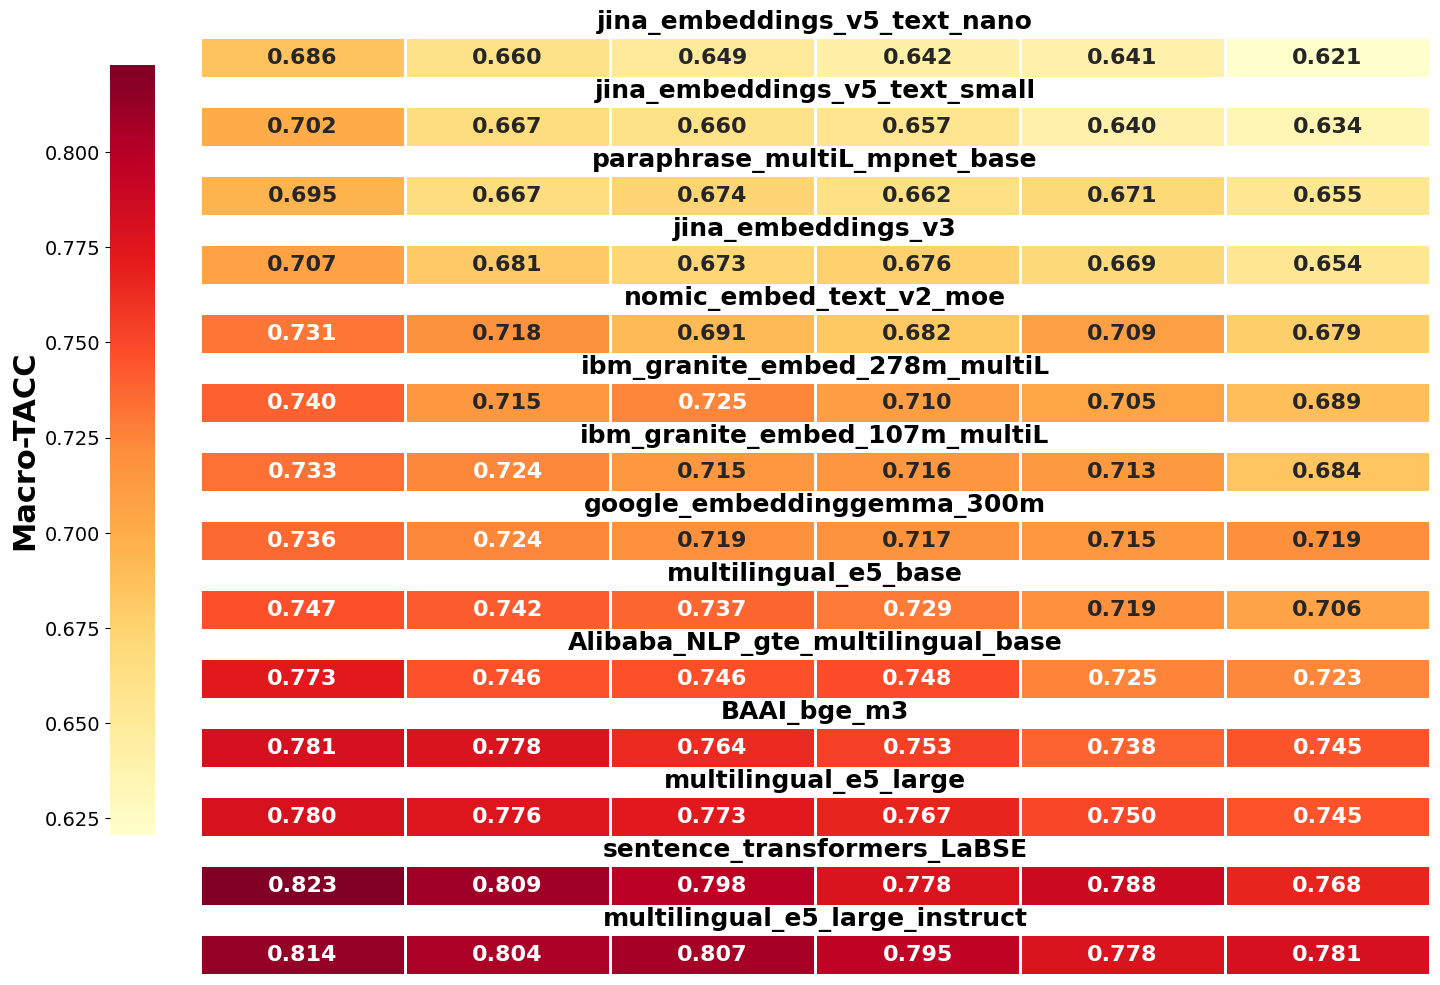

In [34]:
# PLOT: per-model "ribbon" heatmaps — one thin heatmap strip per model across the
# language variants, sharing a single colorbar. Heavily layout-tuned for the paper.

# Per-(model, language-variant) Macro-TACC, pivoted to model × variant (defines _pivot_lang)
_results_by_lang = macro_tacc(_df_lang, ['model', 'lang'])
_pivot_lang = _results_by_lang.pivot(index='model', columns='lang', values='tacc')
_pivot_lang = _pivot_lang.loc[_pivot_lang.mean(axis=1).sort_values(ascending=True).index]

n_models = len(_pivot_lang)
n_cols = len(_pivot_lang.columns)

# 1. FIGSIZE
fig, axes = plt.subplots(
    nrows=n_models,
    ncols=1,
    figsize=(n_cols * 2.5, n_models * 1.0),
    gridspec_kw={'hspace': 0.68}
)

if n_models == 1:
    axes = [axes]

global_min = _pivot_lang.values.min()
global_max = _pivot_lang.values.max()

# 2. Colorbar Axes - NUDGED RIGHT
# Moved from 0.06 to 0.10 to get closer to the heatmap
cbar_ax = fig.add_axes([0.10, 0.35, 0.03, 0.55])

for i, (model_name, row_series) in enumerate(_pivot_lang.iterrows()):
    ax = axes[i]
    row_df = row_series.to_frame().T

    draw_cbar = (i == 0)

    sb.heatmap(
        row_df, annot=True, fmt='.3f', cmap='YlOrRd',
        linewidths=2, linecolor='white',
        ax=ax,
        annot_kws={'fontsize': 16, 'fontweight': 'bold'},
        vmin=global_min, vmax=global_max,
        cbar=draw_cbar,
        cbar_ax=cbar_ax if draw_cbar else None,
        cbar_kws={'label': 'Macro-TACC'} if draw_cbar else None
    )

    if draw_cbar:
        cbar_ax.yaxis.set_label_position('left')
        cbar_ax.yaxis.set_ticks_position('left')
        cbar_ax.yaxis.label.set_size(22)
        cbar_ax.yaxis.label.set_weight('bold')
        cbar_ax.tick_params(labelsize=14)

    ax.set_title(model_name, fontsize=18, fontweight='bold', pad=6)

    ax.set_ylabel('')
    ax.set_xlabel('')
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

# 3. Final Margin Adjustments
# left=0.16 (moved from 0.18) pulls the heatmaps left toward the bar
plt.subplots_adjust(left=0.16, right=0.98, top=0.92, bottom=0.25)

plt.savefig(f'{figures_dir}/ribbon_heatmap_tight_bold_cbar.png', bbox_inches='tight', dpi=150)
plt.show()

In [35]:
# Flat wide results table (model x variant TACC, plus average), and a per-augmentation
# breakdown when multiple language codes are selected.
_results_flat = macro_tacc(_df_lang, ['model', 'lang'])

# Build wide table: model | lang1_tacc | lang2_tacc | ...
_flat_parts = []
for lang_code in sorted(_results_flat['lang'].unique()):
    sub = _results_flat[_results_flat['lang'] == lang_code][['model', 'tacc']].copy()
    sub = sub.rename(columns={'tacc': f'{lang_code}_tacc'})
    _flat_parts.append(sub)

_flat_table = _flat_parts[0]
for part in _flat_parts[1:]:
    _flat_table = _flat_table.merge(part, on='model')

_tacc_cols = [c for c in _flat_table.columns if c.endswith('_tacc')]
_flat_table['avg_tacc'] = _flat_table[_tacc_cols].mean(axis=1).round(3)
_flat_table = _flat_table.sort_values('avg_tacc', ascending=False).reset_index(drop=True)

print(f"=== {DATASET.upper()} — Full results for {LANG_CODES} ===")
print(_flat_table.to_string(index=False))

# Also per augmentation if multiple languages
if len(LANG_CODES) > 1:
    _results_flat_aug = _df_lang.groupby(['model', 'lang', 'aug_category']).apply(
        get_metrics, include_groups=False
    ).reset_index()

    for aug in sorted(_results_flat_aug['aug_category'].unique()):
        sub_aug = _results_flat_aug[_results_flat_aug['aug_category'] == aug]
        _flat_parts_aug = []
        for lang_code in sorted(sub_aug['lang'].unique()):
            sub = sub_aug[sub_aug['lang'] == lang_code][['model', 'tacc']].copy()
            sub = sub.rename(columns={'tacc': lang_code})
            _flat_parts_aug.append(sub)

        _flat_aug = _flat_parts_aug[0]
        for part in _flat_parts_aug[1:]:
            _flat_aug = _flat_aug.merge(part, on='model')

        _lang_cols = [c for c in _flat_aug.columns if c != 'model']
        _flat_aug['avg'] = _flat_aug[_lang_cols].mean(axis=1).round(3)
        _flat_aug = _flat_aug.sort_values('avg', ascending=False).reset_index(drop=True)

        print(f"\n--- {aug} ---")
        print(_flat_aug.to_string(index=False))

/tmp/ipykernel_18426/1559903658.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_aug = df.groupby(groupby_cols + ['aug_category']).apply(
/tmp/ipykernel_18426/1559903658.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  result = per_aug.groupby(groupby_cols)['tacc'].mean().reset_index()
/tmp/ipykernel_18426/3327409954.py:25: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  _results_flat_aug = _df_lang.groupby(['mod

=== WMT — Full results for ['rm_RG', 'rm_SV', 'rm_VA', 'rm_PU', 'rm_SM', 'rm_ST'] ===
                            model  rm_PU_tacc  rm_RG_tacc  rm_SM_tacc  rm_ST_tacc  rm_SV_tacc  rm_VA_tacc  avg_tacc
   multilingual_e5_large_instruct    0.794634    0.813516    0.778334    0.781420    0.803911    0.806586     0.796
      sentence_transformers_LaBSE    0.778273    0.822850    0.787652    0.767524    0.809285    0.798090     0.794
            multilingual_e5_large    0.766871    0.779777    0.750246    0.745266    0.776221    0.772861     0.765
                      BAAI_bge_m3    0.753474    0.780878    0.738392    0.744638    0.777936    0.764210     0.760
Alibaba_NLP_gte_multilingual_base    0.748311    0.773480    0.725494    0.723483    0.745796    0.746466     0.744
             multilingual_e5_base    0.729139    0.746543    0.719261    0.705970    0.742031    0.737212     0.730
       google_embeddinggemma_300m    0.717232    0.735711    0.714633    0.719398    0.723622    0.719

# Subtokenizer expansion analysis

Tests whether heavier subword fragmentation lowers TACC: for each language, the median
number of XLM-R subtokens per text is computed and scatter-plotted against Macro-TACC.
Separate plots for ALEE-MT61, ALEE-F200, and ALEE-BQ275.


In [36]:
# --- Subtoken fragmentation vs Macro-TACC (XLM-RoBERTa tokenizer) ---
# For each language variant in LANG_CODES, compute the median number of
# XLM-R subtokens per text_other, then scatter against TACC.
# Works with whichever DATASET is selected above (flores or wmt).

_xlmr_tok = AutoTokenizer.from_pretrained("xlm-roberta-base")

def _median_subtokens(texts):
    """Median subtoken count across a list of strings."""
    counts = [len(_xlmr_tok.tokenize(t)) for t in texts]
    return np.median(counts)

# Use the same _df and _eng_prefix from the single-language tool setup
_subtok_pairs = [_eng_prefix + lc for lc in LANG_CODES]
_subtok_df = _df[_df['lang_pair'].isin(_subtok_pairs)].copy()

print(f"Dataset: {DATASET}")
print(f"LANG_CODES: {LANG_CODES}")
print(f"Looking for lang_pairs: {_subtok_pairs[:5]}{'...' if len(_subtok_pairs) > 5 else ''}")
print(f"Matched rows: {len(_subtok_df)}")

if len(_subtok_df) == 0:
    print("\nNo matching languages found. Check that LANG_CODES match the selected DATASET.")
else:
    _subtok_df['lang'] = _subtok_df['lang_pair'].str.replace(_eng_prefix, '')

    # One model for tokenization (text is the same across models), deduplicate by (lang, idx)
    _one_m = _subtok_df['model'].unique()[0]
    _df_dedup = _subtok_df[_subtok_df['model'] == _one_m].drop_duplicates(subset=['lang', 'idx'])

    # Median subtokens per lang
    _subtok = _df_dedup.groupby('lang')['text_other'].apply(lambda x: _median_subtokens(x.tolist()))

    # TACC per lang (across all models and augs)
    _tacc = macro_tacc(_subtok_df, ['lang'])
    _merged = _tacc.merge(_subtok.rename('median_subtokens'), on='lang')

    # Plot
    fig, ax = plt.subplots(figsize=(9, 7))
    ax.scatter(_merged['median_subtokens'], _merged['tacc'], alpha=0.7, s=60)
    for _, row in _merged.iterrows():
        ax.annotate(row['lang'], (row['median_subtokens'], row['tacc']),
                    fontsize=8, alpha=0.7, ha='left', va='bottom')

    if len(_merged) > 2:
        r, p = stats.pearsonr(_merged['median_subtokens'], _merged['tacc'])
        rho, p_s = stats.spearmanr(_merged['median_subtokens'], _merged['tacc'])
        z = np.polyfit(_merged['median_subtokens'], _merged['tacc'], 1)
        x_line = np.linspace(_merged['median_subtokens'].min(), _merged['median_subtokens'].max(), 100)
        ax.plot(x_line, np.polyval(z, x_line), 'r--', alpha=0.4)
        ax.set_title(f'{DATASET.upper()} — XLM-R subtoken fragmentation vs Macro-TACC (n={len(_merged)})\n'
                 f'Pearson r={r:.3f} (p={p:.4f}), Spearman ρ={rho:.3f} (p={p_s:.4f})')
    else:
        ax.set_title(f'{DATASET.upper()} — XLM-R subtoken fragmentation vs Macro-TACC (n={len(_merged)})')

    ax.set_xlabel('Median XLM-R subtokens per text', fontsize=14)
    ax.set_ylabel('Macro-TACC', fontsize=14)
    plt.tight_layout()
    plt.savefig(f'{figures_dir}/subtokens_vs_tacc_rumansch--cell90.pdf', bbox_inches='tight')
    plt.close()

    print(_merged[['lang', 'median_subtokens', 'tacc']].sort_values('median_subtokens').to_string(index=False))

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Dataset: wmt
LANG_CODES: ['rm_RG', 'rm_SV', 'rm_VA', 'rm_PU', 'rm_SM', 'rm_ST']
Looking for lang_pairs: ['en_EN-rm_RG', 'en_EN-rm_SV', 'en_EN-rm_VA', 'en_EN-rm_PU', 'en_EN-rm_SM']...
Matched rows: 165900
 lang  median_subtokens     tacc
rm_RG              58.0 0.746200
rm_SV              59.0 0.729310
rm_VA              61.0 0.723784
rm_PU              61.0 0.716698
rm_SM              64.0 0.711579
rm_ST              65.0 0.700191


Languages: 60
Unique texts: 48180

--- ALEE-MT61: Subtoken fragmentation correlations ---
  Pearson r=-0.691 (p=0.0000)
  Spearman rho=-0.516 (p=0.0000)


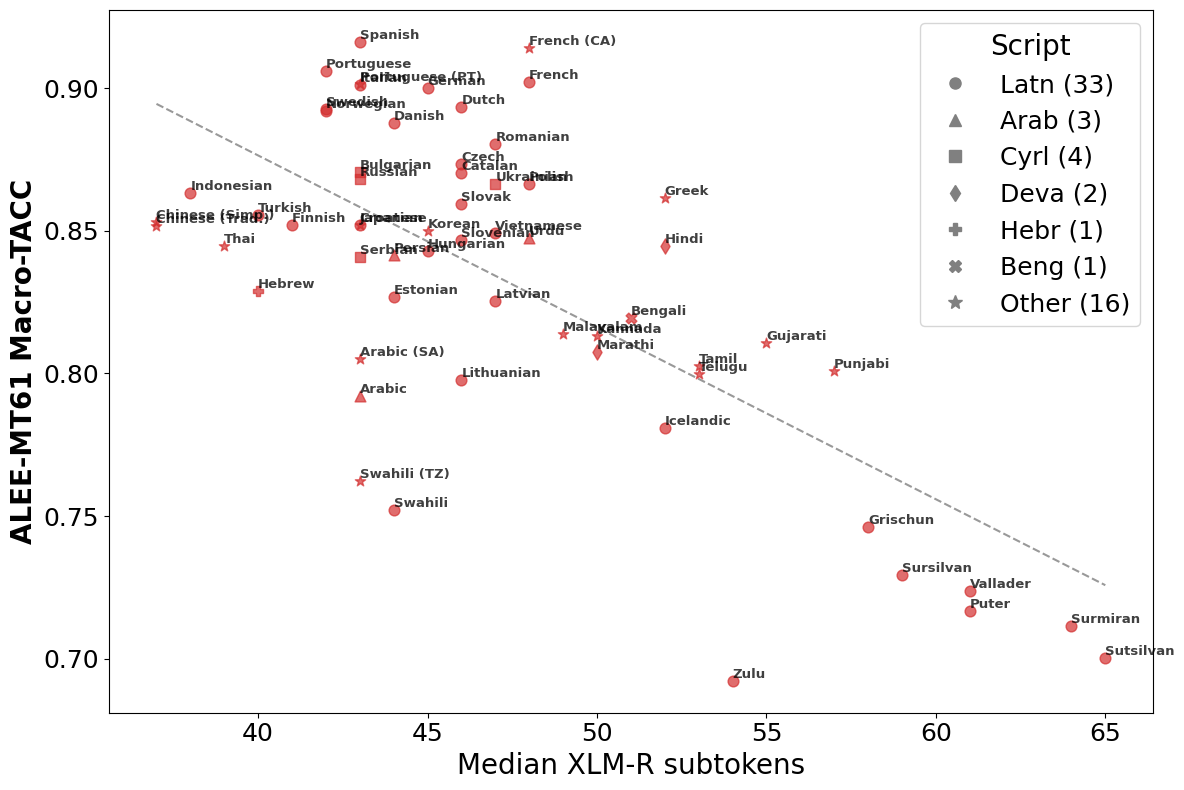

 lang     short_label  script  median_subtokens     tacc
zh_TW Chinese (Trad.)    Hant              37.0 0.851773
zh_CN Chinese (Simp.)    Hans              37.0 0.853080
id_ID      Indonesian    Latn              38.0 0.863070
th_TH            Thai    Thai              39.0 0.844678
tr_TR         Turkish    Latn              40.0 0.855650
he_IL          Hebrew    Hebr              40.0 0.828975
fi_FI         Finnish    Latn              41.0 0.851942
no_NO       Norwegian    Latn              42.0 0.891991
sv_SE         Swedish    Latn              42.0 0.892656
pt_BR      Portuguese    Latn              42.0 0.905969
it_IT         Italian    Latn              43.0 0.900961
ja_JP        Japanese    Jpan              43.0 0.852065
es_MX         Spanish    Latn              43.0 0.916164
ar_EG          Arabic    Arab              43.0 0.792081
bg_BG       Bulgarian    Cyrl              43.0 0.870622
ar_SA     Arabic (SA) Unknown              43.0 0.805047
pt_PT Portuguese (PT) Unknown  

In [37]:
# PLOT: ALEE-MT61 — median XLM-R subtokens per text vs Macro-TACC, all languages.
# Markers by script; Romansh varieties and a few regional variants get readable labels.
# (Re-imports the tokenizer so the cell is self-contained.)
# --- Subtoken fragmentation vs Macro-TACC (XLM-RoBERTa tokenizer) — ALEE-MT61 ---

_xlmr_tok = AutoTokenizer.from_pretrained("xlm-roberta-base")

def _median_subtokens(texts):
    """Median subtoken count across a list of strings."""
    counts = [len(_xlmr_tok.tokenize(t)) for t in texts]
    return np.median(counts)

# Romansh display names
RM_LABELS = {
    'rm_RG': 'Grischun', 'rm_SV': 'Sursilvan', 'rm_VA': 'Vallader',
    'rm_PU': 'Puter', 'rm_SM': 'Surmiran', 'rm_ST': 'Sutsilvan',
}

# Region variants not covered by lang_names
REGION_LABELS = {
    'fr_CA': 'French (CA)', 'pt_PT': 'Portuguese (PT)',
    'ar_SA': 'Arabic (SA)', 'sw_TZ': 'Swahili (TZ)',
}

def _get_script(lang_code):
    """Get script from lang code, treating rm_* as Latn."""
    if lang_code.startswith('rm_'):
        return 'Latn'
    flores_code = wmt_to_flores.get(lang_code)
    if pd.notna(flores_code) and '_' in flores_code:
        return flores_code.split('_')[-1]
    return 'Unknown'

def _get_short_label(lang_code):
    """Get display label: Romansh variety, full language name, region variant, or bare code."""
    if lang_code in RM_LABELS:
        return RM_LABELS[lang_code]
    if lang_code in lang_names:
        return lang_names[lang_code]
    if lang_code in REGION_LABELS:
        return REGION_LABELS[lang_code]
    return lang_code.split('_')[0]

_st_prefix = "en_EN-"
_st_df = df_wmt.copy()
_st_df['lang'] = _st_df['lang_pair'].str.replace(_st_prefix, '')

# Drop English (trivial same-language pairs, ~1.0)
_st_df = _st_df[_st_df['lang'] != 'en_EN']

# One model for tokenization (text is the same across models), deduplicate by (lang, idx)
_one_m = _st_df['model'].unique()[0]
_st_dedup = _st_df[_st_df['model'] == _one_m].drop_duplicates(subset=['lang', 'idx'])

print(f"Languages: {_st_dedup['lang'].nunique()}")
print(f"Unique texts: {len(_st_dedup)}")

# Median subtokens per lang
_subtok = _st_dedup.groupby('lang')['text_other'].apply(lambda x: _median_subtokens(x.tolist()))

# TACC per lang (across all models and augs)
_tacc = macro_tacc(_st_df, ['lang'])
_merged = _tacc.merge(_subtok.rename('median_subtokens'), on='lang')

# Add script and labels
_merged['script'] = _merged['lang'].apply(_get_script)
_merged['short_label'] = _merged['lang'].apply(_get_short_label)

# Script markers (same as other plots)
SCRIPT_MARKERS = {
    'Latn': 'o', 'Arab': '^', 'Cyrl': 's', 'Deva': 'd',
    'Hebr': 'P', 'Beng': 'X',
}
OTHER_MARKER = '*'

# Plot
fig, ax = plt.subplots(figsize=(12, 8))

for _, row in _merged.iterrows():
    marker = SCRIPT_MARKERS.get(row['script'], OTHER_MARKER)
    ax.scatter(row['median_subtokens'], row['tacc'],
               alpha=0.7, s=60, c='#d32f2f', marker=marker, zorder=3)

for _, row in _merged.iterrows():
    ax.annotate(row['short_label'], (row['median_subtokens'], row['tacc']),
                fontsize=9.5, fontweight='bold', alpha=0.75, ha='left', va='bottom')

if len(_merged) > 2:
    r, p = stats.pearsonr(_merged['median_subtokens'], _merged['tacc'])
    rho, p_s = stats.spearmanr(_merged['median_subtokens'], _merged['tacc'])
    z = np.polyfit(_merged['median_subtokens'], _merged['tacc'], 1)
    x_line = np.linspace(_merged['median_subtokens'].min(), _merged['median_subtokens'].max(), 100)
    ax.plot(x_line, np.polyval(z, x_line), 'k--', alpha=0.4)

print(f"\n--- ALEE-MT61: Subtoken fragmentation correlations ---")
print(f"  Pearson r={r:.3f} (p={p:.4f})")
print(f"  Spearman rho={rho:.3f} (p={p_s:.4f})")

# Script legend
script_counts = _merged['script'].value_counts()
named_scripts = set(SCRIPT_MARKERS.keys())
other_count = script_counts[~script_counts.index.isin(named_scripts)].sum()

script_handles = [
    Line2D([0], [0], marker=SCRIPT_MARKERS[s], color='w', markerfacecolor='grey', markeredgecolor='grey',
           markersize=8, label=f'{s} ({script_counts.get(s, 0)})')
    for s in ['Latn', 'Arab', 'Cyrl', 'Deva', 'Hebr', 'Beng'] if script_counts.get(s, 0) > 0
]
if other_count > 0:
    script_handles.append(
        Line2D([0], [0], marker='*', color='w', markerfacecolor='grey', markeredgecolor='grey',
               markersize=10, label=f'Other ({other_count})')
    )
ax.legend(handles=script_handles, loc='upper right', title='Script', fontsize=18, title_fontsize=20, ncol=1)

ax.set_xlabel('Median XLM-R subtokens', fontsize=20)
ax.set_ylabel('ALEE-MT61 Macro-TACC', fontsize=20, fontweight="bold")
ax.tick_params(axis='both', labelsize=18)
plt.tight_layout()
plt.savefig(f'{figures_dir}/subtokens_vs_tacc--cell91.png', bbox_inches='tight')
plt.show()

print(_merged[['lang', 'short_label', 'script', 'median_subtokens', 'tacc']].sort_values('median_subtokens').to_string(index=False))


--- ALEE-F200: Subtoken fragmentation correlations ---
  Pearson r=-0.657 (p=0.0000)
  Spearman rho=-0.786 (p=0.0000)


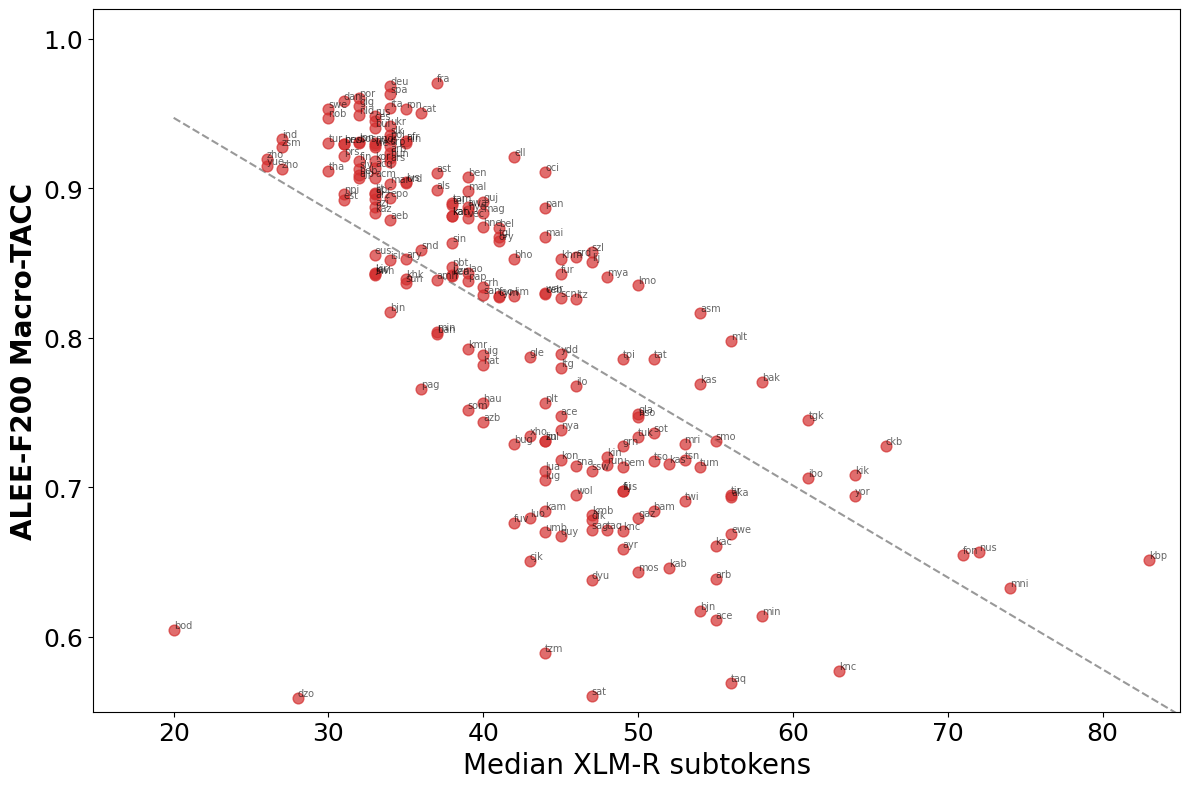

    lang short_label  median_subtokens     tacc
bod_Tibt         bod              20.0 0.604840
zho_Hans         zho              26.0 0.919361
yue_Hant         yue              26.0 0.914834
ind_Latn         ind              27.0 0.932784
zsm_Latn         zsm              27.0 0.928009
zho_Hant         zho              27.0 0.912886
dzo_Tibt         dzo              28.0 0.558913
nob_Latn         nob              30.0 0.947006
swe_Latn         swe              30.0 0.953131
tha_Thai         tha              30.0 0.911415
tur_Latn         tur              30.0 0.930604
dan_Latn         dan              31.0 0.958175
hrv_Latn         hrv              31.0 0.929485
est_Latn         est              31.0 0.892269
npi_Deva         npi              31.0 0.896478
prs_Arab         prs              31.0 0.921697
pes_Arab         pes              31.0 0.929754
heb_Hebr         heb              32.0 0.909291
glg_Latn         glg              32.0 0.954924
slv_Latn         slv              32.0 0

In [38]:
# PLOT: ALEE-F200 — median XLM-R subtokens per text vs Macro-TACC, all languages.
# --- Subtoken fragmentation vs Macro-TACC (XLM-RoBERTa tokenizer) — ALEE-F200 ---

_xlmr_tok = AutoTokenizer.from_pretrained("xlm-roberta-base")

def _median_subtokens(texts):
    """Median subtoken count across a list of strings."""
    counts = [len(_xlmr_tok.tokenize(t)) for t in texts]
    return np.median(counts)

_st_prefix = "eng_Latn-"
_st_df = df_flores.copy()
_st_df['lang'] = _st_df['lang_pair'].str.replace(_st_prefix, '')

# Drop English (trivial same-language pairs, ~1.0)
_st_df = _st_df[_st_df['lang'] != 'eng_Latn']

# One model for tokenization (text is the same across models), deduplicate by (lang, idx)
_one_m = _st_df['model'].unique()[0]
_st_dedup = _st_df[_st_df['model'] == _one_m].drop_duplicates(subset=['lang', 'idx'])

# Median subtokens per lang
_subtok = _st_dedup.groupby('lang')['text_other'].apply(lambda x: _median_subtokens(x.tolist()))

# TACC per lang (across all models and augs)
_tacc = macro_tacc(_st_df, ['lang'])
_merged = _tacc.merge(_subtok.rename('median_subtokens'), on='lang')

# Short label (e.g. 'fra_Latn' -> 'fra')
_merged['short_label'] = _merged['lang'].apply(lambda x: x.split('_')[0])

# Plot
fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(_merged['median_subtokens'], _merged['tacc'], alpha=0.7, s=60, c='#d32f2f', zorder=3)

for _, row in _merged.iterrows():
    ax.annotate(row['short_label'], (row['median_subtokens'], row['tacc']),
                fontsize=7, alpha=0.6, ha='left', va='bottom')

if len(_merged) > 2:
    r, p = stats.pearsonr(_merged['median_subtokens'], _merged['tacc'])
    rho, p_s = stats.spearmanr(_merged['median_subtokens'], _merged['tacc'])
    z = np.polyfit(_merged['median_subtokens'], _merged['tacc'], 1)
    x_line = np.linspace(_merged['median_subtokens'].min(), _merged['median_subtokens'].max(), 100)
    ax.plot(x_line, np.polyval(z, x_line), 'k--', alpha=0.4)

print(f"\n--- ALEE-F200: Subtoken fragmentation correlations ---")
print(f"  Pearson r={r:.3f} (p={p:.4f})")
print(f"  Spearman rho={rho:.3f} (p={p_s:.4f})")

ax.set_xlabel('Median XLM-R subtokens', fontsize=20)
ax.set_ylabel('ALEE-F200 Macro-TACC', fontsize=20, fontweight="bold")
ax.tick_params(axis='both', labelsize=18)
ax.set_xlim(left=None, right=85)
ax.set_ylim(bottom=0.55, top=1.02)
plt.tight_layout()
plt.savefig(f'{figures_dir}/subtokens_vs_tacc_flores--cell92.png', bbox_inches='tight')
plt.show()

print(_merged[['lang', 'short_label', 'median_subtokens', 'tacc']].sort_values('median_subtokens').to_string(index=False))

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (533 > 512). Running this sequence through the model will result in indexing errors



--- ALEE-BQ275: Subtoken fragmentation correlations ---
  Pearson r=-0.678 (p=0.0000)
  Spearman rho=-0.708 (p=0.0000)


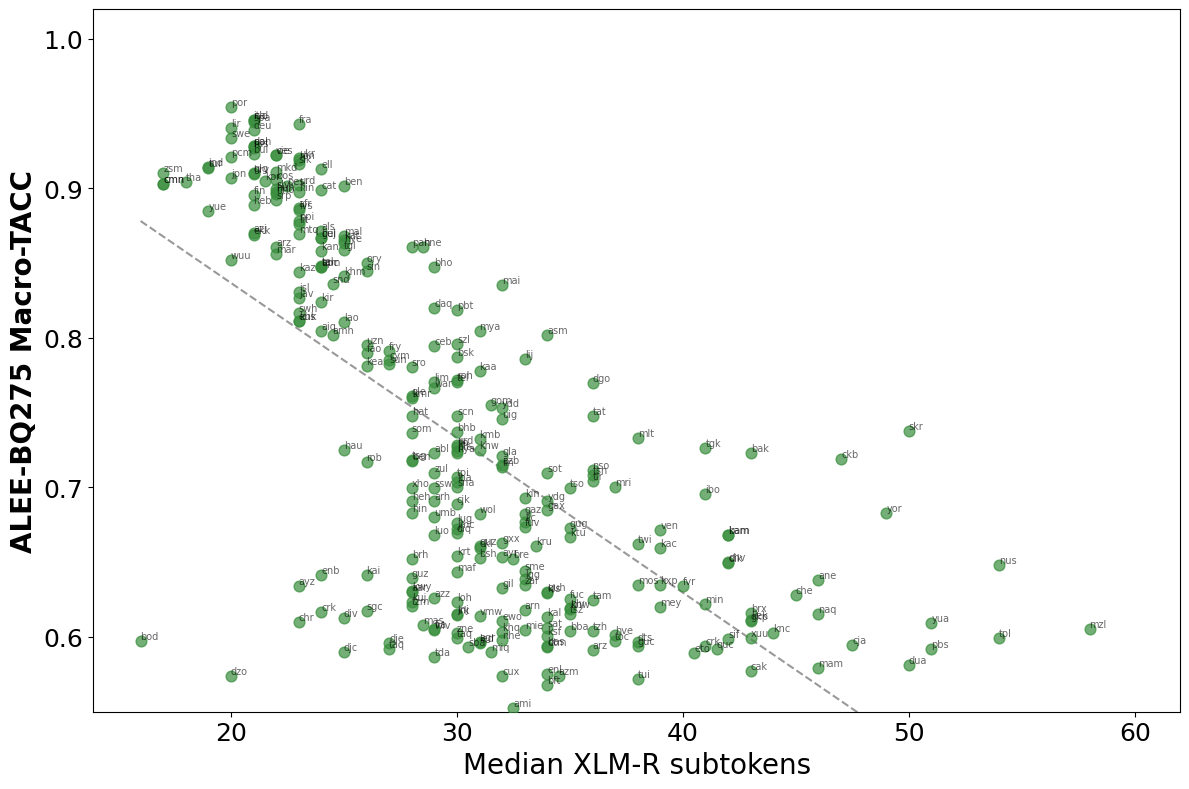

             lang short_label  median_subtokens     tacc
         bod_Tibt         bod              16.0 0.597502
         zsm_Latn         zsm              17.0 0.910602
         cmn_Hans         cmn              17.0 0.903070
         cmn_Hant         cmn              17.0 0.902948
         tha_Thai         tha              18.0 0.904052
         ind_Latn         ind              19.0 0.914157
         tur_Latn         tur              19.0 0.913780
         yue_Hant         yue              19.0 0.884586
         jpn_Jpan         jpn              20.0 0.907245
por_Latn_braz1246         por              20.0 0.954343
         pcm_Latn         pcm              20.0 0.921250
         lir_Latn         lir              20.0 0.940594
         dzo_Tibt         dzo              20.0 0.573929
         swe_Latn         swe              20.0 0.933567
         wuu_Hans         wuu              20.0 0.852456
         dan_Latn         dan              21.0 0.928605
         glg_Latn         glg  

In [39]:
# PLOT: ALEE-BQ275 — median XLM-R subtokens per text vs Macro-TACC, all languages.
# Shan (shn_Mymr) is dropped as an extreme subtoken-count outlier for readability.
# --- Subtoken fragmentation vs Macro-TACC (XLM-RoBERTa tokenizer) — ALEE-BQ275 ---

_xlmr_tok = AutoTokenizer.from_pretrained("xlm-roberta-base")

def _median_subtokens(texts):
    """Median subtoken count across a list of strings."""
    counts = [len(_xlmr_tok.tokenize(t)) for t in texts]
    return np.median(counts)

_st_prefix = "eng_Latn-"
_st_df = df_bouquet.copy()
_st_df['lang'] = _st_df['lang_pair'].str.replace(_st_prefix, '')

# Drop English (trivial same-language pairs, ~1.0)
_st_df = _st_df[_st_df['lang'] != 'eng_Latn']

# Drop Shan for visualization (extreme subtoken outlier)
_st_df = _st_df[_st_df['lang'] != 'shn_Mymr']

# One model for tokenization (text is the same across models), deduplicate by (lang, idx)
_one_m = _st_df['model'].unique()[0]
_st_dedup = _st_df[_st_df['model'] == _one_m].drop_duplicates(subset=['lang', 'idx'])

# Median subtokens per lang
_subtok = _st_dedup.groupby('lang')['text_other'].apply(lambda x: _median_subtokens(x.tolist()))

# TACC per lang (across all models and augs)
_tacc = macro_tacc(_st_df, ['lang'])
_merged = _tacc.merge(_subtok.rename('median_subtokens'), on='lang')

# Short label (e.g. 'fra_Latn' -> 'fra')
_merged['short_label'] = _merged['lang'].apply(lambda x: x.split('_')[0])

# Plot
fig, ax = plt.subplots(figsize=(12, 8))
ax.scatter(_merged['median_subtokens'], _merged['tacc'], alpha=0.7, s=60, c='#388e3c', zorder=3)

for _, row in _merged.iterrows():
    ax.annotate(row['short_label'], (row['median_subtokens'], row['tacc']),
                fontsize=7, alpha=0.6, ha='left', va='bottom')

if len(_merged) > 2:
    r, p = stats.pearsonr(_merged['median_subtokens'], _merged['tacc'])
    rho, p_s = stats.spearmanr(_merged['median_subtokens'], _merged['tacc'])
    z = np.polyfit(_merged['median_subtokens'], _merged['tacc'], 1)
    x_line = np.linspace(_merged['median_subtokens'].min(), _merged['median_subtokens'].max(), 100)
    ax.plot(x_line, np.polyval(z, x_line), 'k--', alpha=0.4)

print(f"\n--- ALEE-BQ275: Subtoken fragmentation correlations ---")
print(f"  Pearson r={r:.3f} (p={p:.4f})")
print(f"  Spearman rho={rho:.3f} (p={p_s:.4f})")

ax.set_xlabel('Median XLM-R subtokens', fontsize=20)
ax.set_ylabel('ALEE-BQ275 Macro-TACC', fontsize=20, fontweight="bold")
ax.tick_params(axis='both', labelsize=18)
ax.set_xlim(left=None, right=62)
ax.set_ylim(bottom=0.55, top=1.02)
plt.tight_layout()
plt.savefig(f'{figures_dir}/subtokens_vs_tacc_bouquet--cell92.png', bbox_inches='tight')
plt.show()

print(_merged[['lang', 'short_label', 'median_subtokens', 'tacc']].sort_values('median_subtokens').to_string(index=False))

# LaTeX appendix table generation

Self-contained code that re-loads the similarity data and emits LaTeX appendix tables
of per-language x per-model x per-augmentation TACC. Languages are partitioned by which
datasets contain them. A second cell generates the separate MT61-only table for
regional variants that have no FLORES mapping.


In [42]:
"""
Generate LaTeX appendix tables: per-language, per-model, per-augmentation TACC.

Reads the same data as the evaluation notebook (JSON similarity files).
Outputs LaTeX table* environments ready to paste into a paper.

Languages are partitioned by which datasets contain them:
    - all three (F200 + MT61 + BQ275)
    - each pair (F200+MT61, MT61+BQ275, F200+BQ275)
    - each solo (F200-only, MT61-only, BQ275-only)
Each language appears in exactly one table.

Usage:
    1. Ensure similarities_dir (set in the data-loading cell) points to your
       similarities folder; this cell reuses it.
    2. Run: python generate_appendix_tables.py
    3. Copy the contents of appendix_tables_output.tex into your paper.
"""

# ===================== CONFIG =====================

# Reuse the similarities_dir defined in the data-loading cell above
# (Google Drive path by default, or "intermediate_outputs/similarities" for a
# flat local folder). Falls back to the Drive default if it was never set.
similarities_dir = globals().get("similarities_dir", "drive/MyDrive/AMR/similarities")
OUTPUT_FILE = "appendix_tables_output.tex"

LANGS_PER_SUBTABLE_ALL = 4     # 4 langs x 12 cols = 48 data cols
LANGS_PER_SUBTABLE_PAIR = 5    # 5 langs x 8 cols  = 40 data cols
LANGS_PER_SUBTABLE_SINGLE = 10  # 10 langs x 4 cols = 40 data cols
SUBTABLES_PER_PAGE = 7

# ===================== MAPPINGS =====================

# WMT code -> FLORES code (for overlapping languages)
WMT_TO_FLORES = {
    "ar_EG": "arb_Arab", "bg_BG": "bul_Cyrl", "bn_IN": "ben_Beng",
    "ca_ES": "cat_Latn", "cs_CZ": "ces_Latn", "da_DK": "dan_Latn",
    "de_DE": "deu_Latn", "el_GR": "ell_Grek", "es_MX": "spa_Latn",
    "et_EE": "est_Latn", "fa_IR": "pes_Arab", "fi_FI": "fin_Latn",
    "fil_PH": "tgl_Latn", "fr_FR": "fra_Latn", "gu_IN": "guj_Gujr",
    "he_IL": "heb_Hebr", "hi_IN": "hin_Deva", "hr_HR": "hrv_Latn",
    "hu_HU": "hun_Latn", "id_ID": "ind_Latn", "is_IS": "isl_Latn",
    "it_IT": "ita_Latn", "ja_JP": "jpn_Jpan", "kn_IN": "kan_Knda",
    "ko_KR": "kor_Hang", "lt_LT": "lit_Latn", "lv_LV": "lvs_Latn",
    "ml_IN": "mal_Mlym", "mr_IN": "mar_Deva", "nl_NL": "nld_Latn",
    "no_NO": "nob_Latn", "pa_IN": "pan_Guru", "pl_PL": "pol_Latn",
    "pt_BR": "por_Latn", "ro_RO": "ron_Latn", "ru_RU": "rus_Cyrl",
    "sk_SK": "slk_Latn", "sl_SI": "slv_Latn", "sr_RS": "srp_Cyrl",
    "sv_SE": "swe_Latn", "sw_KE": "swh_Latn", "ta_IN": "tam_Taml",
    "te_IN": "tel_Telu", "th_TH": "tha_Thai", "tr_TR": "tur_Latn",
    "uk_UA": "ukr_Cyrl", "ur_PK": "urd_Arab", "vi_VN": "vie_Latn",
    "zh_CN": "zho_Hans", "zh_TW": "zho_Hant", "zu_ZA": "zul_Latn",
}
FLORES_TO_WMT = {v: k for k, v in WMT_TO_FLORES.items()}

AUG_ORDER = ["antonym_replacement", "hypernym_substitution",
             "polarity_negation", "role_swap"]
AUG_SHORT = {"antonym_replacement": "AR", "hypernym_substitution": "HS",
             "polarity_negation": "PN", "role_swap": "RS"}

# ===================== DATA LOADING =====================

def load_data(similarities_dir):
    """Load all JSON similarity files into df_flores, df_wmt and df_bouquet."""
    dfs = {}
    for aug_category in os.listdir(similarities_dir):
        aug_path = os.path.join(similarities_dir, aug_category)
        if not os.path.isdir(aug_path):
            continue
        dfs[aug_category] = {}
        for file in os.listdir(aug_path):
            if not file.endswith('.json'):
                continue
            filepath = os.path.join(aug_path, file)
            df = pd.read_json(filepath, lines=True)
            model_name = (df['model'][0] if "-" not in df['model'][0]
                          else df['model'][0].split('-')[0])
            df['model'] = model_name
            dataset = df['dataset'][0]
            if dataset in dfs[aug_category]:
                dfs[aug_category][dataset][model_name] = df
            else:
                dfs[aug_category][dataset] = {model_name: df}

    dataset_dfs = defaultdict(list)
    for aug_category, datasets in dfs.items():
        for dataset, model_dfs in datasets.items():
            for model_name, df in model_dfs.items():
                df = df.copy()
                df['aug_category'] = aug_category
                dataset_dfs[dataset].append(df)

    df_wmt = pd.concat(dataset_dfs['wmt24pp'], ignore_index=True)
    df_flores = pd.concat(dataset_dfs['flores200'], ignore_index=True)
    df_bouquet = pd.concat(dataset_dfs['bouquet'], ignore_index=True)
    return df_wmt, df_flores, df_bouquet

# ===================== METRICS =====================

def get_tacc(sims_pos, sims_neg):
    binary = [1 if p > n else 0 for p, n in zip(sims_pos, sims_neg)]
    return sum(binary) / len(binary)

def compute_results(df, lang_col, aug_col='aug_category'):
    """Compute TACC per (model, lang, aug_category)."""
    def _metrics(g):
        tacc = get_tacc(g['sim_parallel'], g['sim_x_neg'])
        return pd.Series({'tacc': round(tacc, 3)})

    results = (df.groupby(['model', lang_col, aug_col])
               .apply(_metrics, include_groups=False)
               .reset_index())
    return results

# ===================== LANGUAGE CATEGORIZATION =====================

def categorize_languages(df_wmt, df_flores, df_bouquet):
    """
    Partition every language into one of seven groups by dataset membership.

    Membership is decided in FLORES code space:
      - F200:  FLORES code appears in df_flores
      - BQ275: FLORES code appears in df_bouquet (FLORES-style codes)
      - MT61:  FLORES code maps back to a WMT code present in df_wmt

    Returns a dict keyed by group name, each a sorted list of FLORES codes:
      'all3', 'f200_mt61', 'mt61_bq275', 'f200_bq275',
      'f200_only', 'mt61_only', 'bq275_only'
    """
    wmt_langs = set(
        df_wmt['lang_pair'].str.replace('en_EN-', '').unique()
    ) - {'en_EN'}
    flores_langs = set(
        df_flores['lang_pair'].str.replace('eng_Latn-', '').unique()
    ) - {'eng_Latn'}
    bouquet_langs = set(
        df_bouquet['lang_pair'].str.replace('eng_Latn-', '').unique()
    ) - {'eng_Latn'}

    # MT61 languages expressed as FLORES codes (only those with a mapping).
    mt61_flores = {
        WMT_TO_FLORES[w] for w in wmt_langs if w in WMT_TO_FLORES
    }

    # Universe of all FLORES codes seen anywhere.
    all_flores = flores_langs | bouquet_langs | mt61_flores

    groups = {
        'all3': [], 'f200_mt61': [], 'mt61_bq275': [], 'f200_bq275': [],
        'f200_only': [], 'mt61_only': [], 'bq275_only': [],
    }

    for code in all_flores:
        in_f200 = code in flores_langs
        in_bq275 = code in bouquet_langs
        in_mt61 = code in mt61_flores
        key = (in_f200, in_mt61, in_bq275)

        if key == (True, True, True):
            groups['all3'].append(code)
        elif key == (True, True, False):
            groups['f200_mt61'].append(code)
        elif key == (False, True, True):
            groups['mt61_bq275'].append(code)
        elif key == (True, False, True):
            groups['f200_bq275'].append(code)
        elif key == (True, False, False):
            groups['f200_only'].append(code)
        elif key == (False, True, False):
            groups['mt61_only'].append(code)
        elif key == (False, False, True):
            groups['bq275_only'].append(code)

    for k in groups:
        groups[k].sort(key=lambda c: c[:3])
    return groups

def flores_display(code):
    """Convert 'ace_Arab' to 'ace\\_Arab' for LaTeX."""
    return code.replace("_", "\\_")

# ===================== RESULT TABLES =====================

def build_result_dict(results_df, lang_col):
    """
    Build nested dict: result[model][lang][aug] = tacc_value
    """
    d = {}
    for _, row in results_df.iterrows():
        m = row['model']
        l = row[lang_col]
        a = row['aug_category']
        d.setdefault(m, {}).setdefault(l, {})[a] = row['tacc']
    return d

# ===================== LATEX GENERATION =====================

def escape_model(name):
    """Escape underscores in model names for LaTeX."""
    return name.replace("_", "\\_")

def format_val(val):
    """Format TACC value as .XXX"""
    if val is None:
        return "---"
    return f".{val:.3f}"[1:]  # e.g. 0.912 -> .912

def make_subtable(models, lang_codes, datasets, results_by_dataset,
                  dataset_label, is_first=False):
    """
    Generate one subtable for any combination of datasets.

    lang_codes:          list of FLORES codes for this subtable.
    datasets:            ordered list of dataset keys to show per language,
                         e.g. ['F200', 'MT61', 'BQ275'] or ['MT61', 'BQ275'].
    results_by_dataset:  {dataset_key: result_dict}, each result_dict keyed by
                         the lang code used in that dataset (FLORES, except
                         MT61 which is keyed by WMT code).
    dataset_label:       text for the top-left cell.

    All FLORES codes are translated to the dataset's native key via
    FLORES_TO_WMT for MT61; other datasets use the FLORES code directly.
    """
    n_langs = len(lang_codes)
    n_ds = len(datasets)
    block = n_ds * 4              # cols per language
    n_data_cols = n_langs * block
    lines = []

    if not is_first:
        lines.append("\\vspace{1.5mm}")

    lines.append("\\begin{adjustbox}{max width=\\textwidth}")
    lines.append("\\tiny")
    lines.append("\\setlength{\\tabcolsep}{1.5pt}")
    lines.append("\\renewcommand{\\arraystretch}{0.88}")
    lines.append(f"\\begin{{tabular}}{{@{{}}l *{{{n_data_cols}}}{{c}}@{{}}}}")
    lines.append("\\toprule")

    # Row 1: Language names (FLORES display codes)
    lang_headers = []
    for code in lang_codes:
        display = flores_display(code)
        lang_headers.append(
            f"\\multicolumn{{{block}}}{{c}}{{\\textbf{{{display}}}}}")
    lines.append("& " + "\n& ".join(lang_headers) + " \\\\")

    # cmidrules for language groups
    rules = []
    for i in range(n_langs):
        s = 2 + i * block
        rules.append(f"\\cmidrule(lr){{{s}-{s + block - 1}}}")
    lines.append("".join(rules))

    # Row 2: dataset sub-headers (only when >1 dataset per language)
    if n_ds > 1:
        ds_parts = []
        for _ in range(n_langs):
            ds_parts.append(" & ".join(
                f"\\multicolumn{{4}}{{c}}{{{ds}}}" for ds in datasets))
        lines.append(f"\\textbf{{{dataset_label}}}\n& "
                     + "\n& ".join(ds_parts) + " \\\\")

        rules2 = []
        for i in range(n_langs * n_ds):
            s = 2 + i * 4
            rules2.append(f"\\cmidrule(lr){{{s}-{s + 3}}}")
        lines.append("".join(rules2))

        # Row 3: AR HS PN RS repeated
        lines.append("& " + " & ".join(["\\augrow"] * (n_langs * n_ds))
                     + " \\\\")
    else:
        # Single dataset: label sits on the aug-header row.
        lines.append(f"\\textbf{{{dataset_label}}} & "
                     + " & ".join(["\\augrow"] * n_langs) + " \\\\")

    lines.append("\\midrule")

    # Data rows
    for model in models:
        vals = []
        for code in lang_codes:
            for ds in datasets:
                res = results_by_dataset[ds]
                key = FLORES_TO_WMT[code] if ds == 'MT61' else code
                for aug in AUG_ORDER:
                    v = res.get(model, {}).get(key, {}).get(aug)
                    vals.append(format_val(v))

        model_escaped = escape_model(model)
        pad = " " * max(0, 45 - len(model_escaped))
        lines.append(f"{model_escaped}{pad} & {' & '.join(vals)} \\\\")

    lines.append("\\bottomrule")
    lines.append("\\end{tabular}")
    lines.append("\\end{adjustbox}")
    return "\n".join(lines)

def chunk_list(lst, size):
    """Split list into chunks of given size."""
    for i in range(0, len(lst), size):
        yield lst[i:i + size]

def build_table(subtable_texts, subtables_per_page=SUBTABLES_PER_PAGE):
    """
    Wrap subtable texts into table* environments, with page breaks.
    """
    pages = list(chunk_list(subtable_texts, subtables_per_page))
    out = []
    for page_idx, page_subtables in enumerate(pages):
        out.append("\\begin{table*}[!p]")
        out.append("\n\n".join(page_subtables))
        out.append("\\end{table*}")
        if page_idx < len(pages) - 1:
            out.append("")
            out.append("\\clearpage")
            out.append("")
    return "\n".join(out)

# ===================== MAIN =====================

def main():
    print("Loading data...")
    df_wmt, df_flores, df_bouquet = load_data(similarities_dir)

    print("Categorizing languages...")
    groups = categorize_languages(df_wmt, df_flores, df_bouquet)
    for name, codes in groups.items():
        print(f"  {name:12s} {len(codes)} languages")

    models = sorted(df_wmt['model'].unique())
    print(f"  Models:    {len(models)}")

    # --- Compute per (model, lang, aug) TACC for each dataset ---

    print("Computing TACC for ALEE-F200 (all languages)...")
    df_flores_all = df_flores.copy()
    df_flores_all['lang'] = df_flores_all['lang_pair'].str.replace(
        'eng_Latn-', '')
    res_f200 = build_result_dict(
        compute_results(df_flores_all, 'lang'), 'lang')

    print("Computing TACC for ALEE-MT61 (all languages)...")
    df_wmt_all = df_wmt.copy()
    df_wmt_all['lang'] = df_wmt_all['lang_pair'].str.replace('en_EN-', '')
    res_mt61 = build_result_dict(
        compute_results(df_wmt_all, 'lang'), 'lang')

    print("Computing TACC for ALEE-BQ275 (all languages)...")
    df_bq_all = df_bouquet.copy()
    df_bq_all['lang'] = df_bq_all['lang_pair'].str.replace('eng_Latn-', '')
    res_bq275 = build_result_dict(
        compute_results(df_bq_all, 'lang'), 'lang')

    results_by_dataset = {
        'F200': res_f200, 'MT61': res_mt61, 'BQ275': res_bq275,
    }

    # --- Table definitions: (group_key, datasets, label, langs_per_subtable) ---
    table_specs = [
        ('all3', ['F200', 'MT61', 'BQ275'],
         'ALEE-F200/MT61/BQ275 TACC', LANGS_PER_SUBTABLE_ALL,
         'TABLE A1: All three (F200 + MT61 + BQ275)'),
        ('f200_mt61', ['F200', 'MT61'],
         'ALEE-F200/MT61 TACC', LANGS_PER_SUBTABLE_PAIR,
         'TABLE A2: ALEE-F200 + ALEE-MT61'),
        ('mt61_bq275', ['MT61', 'BQ275'],
         'ALEE-MT61/BQ275 TACC', LANGS_PER_SUBTABLE_PAIR,
         'TABLE A3: ALEE-MT61 + ALEE-BQ275'),
        ('f200_bq275', ['F200', 'BQ275'],
         'ALEE-F200/BQ275 TACC', LANGS_PER_SUBTABLE_PAIR,
         'TABLE A4: ALEE-F200 + ALEE-BQ275'),
        ('f200_only', ['F200'],
         'ALEE-F200 TACC', LANGS_PER_SUBTABLE_SINGLE,
         'TABLE A5: ALEE-F200 only'),
        ('mt61_only', ['MT61'],
         'ALEE-MT61 TACC', LANGS_PER_SUBTABLE_SINGLE,
         'TABLE A6: ALEE-MT61 only'),
        ('bq275_only', ['BQ275'],
         'ALEE-BQ275 TACC', LANGS_PER_SUBTABLE_SINGLE,
         'TABLE A7: ALEE-BQ275 only'),
    ]

    print("Generating LaTeX...")
    parts = []
    parts.append("% Auto-generated appendix tables")
    parts.append("% Requires: \\usepackage{booktabs, adjustbox}")
    parts.append("% Place \\newcommand{\\augrow}{AR & HS & PN & RS} in preamble")
    parts.append("")

    summary = []
    for i, (key, datasets, label, per_sub, comment) in enumerate(table_specs):
        codes = groups[key]
        subtables = []
        for chunk in chunk_list(codes, per_sub):
            st = make_subtable(
                models, chunk, datasets, results_by_dataset, label,
                is_first=(len(subtables) == 0))
            subtables.append(st)

        parts.append(f"% {comment} "
                     f"({len(codes)} languages, {len(subtables)} subtables)")
        parts.append(build_table(subtables))
        if i < len(table_specs) - 1:
            parts.append("")
            parts.append("\\clearpage")
            parts.append("")

        n_pages = math.ceil(len(subtables) / SUBTABLES_PER_PAGE) if subtables else 0
        summary.append((label, len(codes), len(subtables), n_pages))

    with open(OUTPUT_FILE, 'w') as f:
        f.write("\n".join(parts))

    print(f"\nWritten to {OUTPUT_FILE}")
    total_pages = 0
    for label, n_lang, n_sub, n_pages in summary:
        total_pages += n_pages
        print(f"  {label:28s} {n_lang:3d} langs, "
              f"{n_sub:2d} subtables -> {n_pages} pages")
    print(f"  Total: ~{total_pages} pages")

if __name__ == "__main__":
    main()

Loading data...
Categorizing languages...
  all3         43 languages
  f200_mt61    7 languages
  mt61_bq275   0 languages
  f200_bq275   100 languages
  f200_only    53 languages
  mt61_only    0 languages
  bq275_only   131 languages
  Models:    14
Computing TACC for ALEE-F200 (all languages)...
Computing TACC for ALEE-MT61 (all languages)...
Computing TACC for ALEE-BQ275 (all languages)...
Generating LaTeX...

Written to appendix_tables_output.tex
  ALEE-F200/MT61/BQ275 TACC     43 langs, 11 subtables -> 2 pages
  ALEE-F200/MT61 TACC            7 langs,  2 subtables -> 1 pages
  ALEE-MT61/BQ275 TACC           0 langs,  0 subtables -> 0 pages
  ALEE-F200/BQ275 TACC         100 langs, 20 subtables -> 3 pages
  ALEE-F200 TACC                53 langs,  6 subtables -> 1 pages
  ALEE-MT61 TACC                 0 langs,  0 subtables -> 0 pages
  ALEE-BQ275 TACC              131 langs, 14 subtables -> 2 pages
  Total: ~9 pages


In [44]:
# Generates the separate ALEE-MT61-only LaTeX table for regional variants that have no
# FLORES mapping (Arabic-SA, French-CA, Portuguese-PT, Swahili-TZ, and the Romansh
# varieties). Reuses the helpers/data loaded in the LaTeX-generation cell above.
# ===================== MT61-ONLY TABLE (unmapped regional variants) =====================

WMT_TO_FLORES_MT61_ONLY = {
    "ar_SA": "arb_SA_Arab",       # Arabic (Saudi)
    "fr_CA": "fra_CA_Latn",       # French (Canada)
    "pt_PT": "por_PT_Latn",       # Portuguese (Portugal)
    "sw_TZ": "swh_TZ_Latn",       # Swahili (Tanzania)
    "rm_PU": "roh_puter",         # Romansh - Puter
    "rm_RG": "roh_rumgr",         # Romansh - Rumantsch Grischun
    "rm_SM": "roh_surmiran",      # Romansh - Surmiran
    "rm_ST": "roh_sutsilv",       # Romansh - Sutsilvan
    "rm_SV": "roh_sursilv",       # Romansh - Sursilvan
    "rm_VA": "roh_vallader",      # Romansh - Vallader
}

mt61_only_wmt = sorted(WMT_TO_FLORES_MT61_ONLY)
models = sorted(df_wmt['model'].unique())

# Compute per (model, wmt_lang, aug) TACC for just these languages.
df_mt61_only = df_wmt[
    df_wmt['lang_pair'].str.replace('en_EN-', '').isin(mt61_only_wmt)
].copy()
df_mt61_only['lang'] = df_mt61_only['lang_pair'].str.replace('en_EN-', '')
res_mt61_only = build_result_dict(
    compute_results(df_mt61_only, 'lang'), 'lang')

def make_subtable_wmt(models, wmt_codes, results, display_map,
                      dataset_label, is_first=False):
    """
    Single-dataset subtable keyed directly by WMT code (no FLORES round-trip).
    Mirrors make_subtable's single-dataset layout.
    """
    n_langs = len(wmt_codes)
    block = 4  # one dataset, 4 augmentations
    n_data_cols = n_langs * block
    lines = []

    if not is_first:
        lines.append("\\vspace{1.5mm}")

    lines.append("\\begin{adjustbox}{max width=\\textwidth}")
    lines.append("\\tiny")
    lines.append("\\setlength{\\tabcolsep}{1.5pt}")
    lines.append("\\renewcommand{\\arraystretch}{0.88}")
    lines.append(f"\\begin{{tabular}}{{@{{}}l *{{{n_data_cols}}}{{c}}@{{}}}}")
    lines.append("\\toprule")

    # Row 1: language headers (FLORES-style display, fall back to WMT code).
    lang_headers = []
    for w in wmt_codes:
        display = flores_display(display_map.get(w, w))
        lang_headers.append(
            f"\\multicolumn{{{block}}}{{c}}{{\\textbf{{{display}}}}}")
    lines.append("& " + "\n& ".join(lang_headers) + " \\\\")

    rules = []
    for i in range(n_langs):
        s = 2 + i * block
        rules.append(f"\\cmidrule(lr){{{s}-{s + block - 1}}}")
    lines.append("".join(rules))

    # Single dataset: label sits on the aug-header row.
    lines.append(f"\\textbf{{{dataset_label}}} & "
                 + " & ".join(["\\augrow"] * n_langs) + " \\\\")
    lines.append("\\midrule")

    # Data rows.
    for model in models:
        vals = []
        for w in wmt_codes:
            for aug in AUG_ORDER:
                v = results.get(model, {}).get(w, {}).get(aug)
                vals.append(format_val(v))
        model_escaped = escape_model(model)
        pad = " " * max(0, 45 - len(model_escaped))
        lines.append(f"{model_escaped}{pad} & {' & '.join(vals)} \\\\")

    lines.append("\\bottomrule")
    lines.append("\\end{tabular}")
    lines.append("\\end{adjustbox}")
    return "\n".join(lines)

# Build the table (chunked like the other single-dataset tables).
subtables = []
for chunk in chunk_list(mt61_only_wmt, LANGS_PER_SUBTABLE_SINGLE):
    st = make_subtable_wmt(
        models, chunk, res_mt61_only, WMT_TO_FLORES_MT61_ONLY,
        'ALEE-MT61 TACC', is_first=(len(subtables) == 0))
    subtables.append(st)

mt61_only_latex = build_table(subtables)
print(mt61_only_latex)

\begin{table*}[!p]
\begin{adjustbox}{max width=\textwidth}
\tiny
\setlength{\tabcolsep}{1.5pt}
\renewcommand{\arraystretch}{0.88}
\begin{tabular}{@{}l *{40}{c}@{}}
\toprule
& \multicolumn{4}{c}{\textbf{arb\_SA\_Arab}}
& \multicolumn{4}{c}{\textbf{fra\_CA\_Latn}}
& \multicolumn{4}{c}{\textbf{por\_PT\_Latn}}
& \multicolumn{4}{c}{\textbf{roh\_puter}}
& \multicolumn{4}{c}{\textbf{roh\_rumgr}}
& \multicolumn{4}{c}{\textbf{roh\_surmiran}}
& \multicolumn{4}{c}{\textbf{roh\_sutsilv}}
& \multicolumn{4}{c}{\textbf{roh\_sursilv}}
& \multicolumn{4}{c}{\textbf{roh\_vallader}}
& \multicolumn{4}{c}{\textbf{swh\_TZ\_Latn}} \\
\cmidrule(lr){2-5}\cmidrule(lr){6-9}\cmidrule(lr){10-13}\cmidrule(lr){14-17}\cmidrule(lr){18-21}\cmidrule(lr){22-25}\cmidrule(lr){26-29}\cmidrule(lr){30-33}\cmidrule(lr){34-37}\cmidrule(lr){38-41}
\textbf{ALEE-MT61 TACC} & \augrow & \augrow & \augrow & \augrow & \augrow & \augrow & \augrow & \augrow & \augrow & \augrow \\
\midrule
Alibaba\_NLP\_gte\_multilingual\_base         & 0

# Big models examination (Qwen decoder family)

Case study comparing the decoder-based Qwen3-Embedding models against selected encoder
baselines. Produces a compact main-text table and a full per-augmentation appendix
breakdown.


In [40]:
# ============================================================================
# 5.6 CASE STUDY — DECODER-BASED MODELS (Qwen family)
# Builds: (1) compact main-text table, (2) full appendix breakdown by negative.
# Paste AFTER the augmentation cell that defines `avg_by_aug`.
# Per-dataset Macro-TACC over ALL languages each model was scored on, per dataset,
# with no overlap filtering and no cross-dataset joins: TACC per (model, lang, aug),
# averaged over languages then over the four augmentations. Average and ranking use
# the three ALEE datasets only. Romansh (six rm_* varieties) is part of the ALEE-MT61
# average and also shown as its own column for reference.
# Main table uses short display names; appendix uses full source names.
# ============================================================================

# --- config: models in the main table (besides the Qwen rows) ---
QWEN_MODELS = ['Qwen3_Embedding_0.6B', 'Qwen3_Embedding_4B', 'Qwen3_Embedding_8B']
MAIN_TABLE_EXTRA_MODELS = [
    'sentence_transformers_LaBSE',
    'Alibaba_NLP_gte_multilingual_base',
    'ibm_granite_embed_107m_multiL',
]

# short display names used ONLY in the main-text table (appendix keeps full names)
MAIN_SHORT_NAME = {
    'sentence_transformers_LaBSE': 'LaBSE',
    'Qwen3_Embedding_0.6B': 'Qwen3-Emb-0.6B',
    'Qwen3_Embedding_4B': 'Qwen3-Emb-4B',
    'Qwen3_Embedding_8B': 'Qwen3-Emb-8B',
    'Alibaba_NLP_gte_multilingual_base': 'gte-multiL-base',
    'ibm_granite_embed_107m_multiL': 'granite_embed107m',
}

ROMANSH_CODES = ['rm_RG', 'rm_SV', 'rm_VA', 'rm_PU', 'rm_SM', 'rm_ST']
AUG_ORDER = ['polarity_negation', 'role_swap', 'antonym_replacement', 'hypernym_substitution']
AUG_SHORT = {'polarity_negation': 'PN', 'role_swap': 'RS',
             'antonym_replacement': 'AR', 'hypernym_substitution': 'HS'}

# Normalize aug labels (snake_case or display names) to short codes.
_AUG_TO_SHORT = dict(AUG_SHORT)
_AUG_TO_SHORT.update({'Polarity Negation': 'PN', 'Role Swap': 'RS',
                      'Antonym Replacement': 'AR', 'Hypernym Substitution': 'HS'})
SHORT_ORDER = ['PN', 'RS', 'AR', 'HS']

def _tex(m):  # escape underscores for LaTeX
    return m.replace('_', r'\_')

# --- per-(model, lang, aug, dataset) TACC over all languages (no intersection) ---
def _per_dataset_tacc(df, prefix, dataset):
    d = df.copy()
    d['lang'] = d['lang_pair'].str.replace(prefix, '', regex=False)
    out = (d.groupby(['model', 'lang', 'aug_category'])
             .apply(get_metrics, include_groups=False)
             .reset_index())
    out['aug'] = out['aug_category'].map(_AUG_TO_SHORT)
    out['dataset'] = dataset
    return out

_perf = pd.concat([
    _per_dataset_tacc(df_flores,  'eng_Latn-', 'ALEE-F200'),
    _per_dataset_tacc(df_wmt,     'en_EN-',    'ALEE-MT61'),
    _per_dataset_tacc(df_bouquet, 'eng_Latn-', 'ALEE-BQ275'),
], ignore_index=True)

# --- 1. per-dataset Macro-TACC, from avg_by_aug (all languages, per dataset) -----
# avg_by_aug holds per-(model, aug_category) macro-TACC per dataset column.
# Average over the four augmentations to get per-model, per-dataset means.
DS_COL = {'ALEE-F200': 'flores', 'ALEE-MT61': 'wmt', 'ALEE-BQ275': 'bouquet'}
overall = pd.DataFrame({
    ds: avg_by_aug.groupby('model')[col].mean() for ds, col in DS_COL.items()
})

# Romansh column (reference only): the six rm_* varieties from ALEE-MT61.
# Part of the ALEE-MT61 average above; repeated here as its own column.
_rom = _perf[(_perf['dataset'] == 'ALEE-MT61') & (_perf['lang'].isin(ROMANSH_CODES))]
overall['Romansh'] = (_rom.groupby(['model', 'aug'])['tacc'].mean()
                          .groupby('model').mean())

overall['Average'] = overall[['ALEE-F200', 'ALEE-MT61', 'ALEE-BQ275']].mean(axis=1)  # 3 ALEE datasets, excludes Romansh
overall = overall.sort_values('Average', ascending=False)
overall.insert(0, 'Overall Rank', range(1, len(overall) + 1))

print("=== Overall (all models, ranked; Romansh shown for reference) ===")
print(overall.round(3).to_string())

# --- 2. main-text table: Qwen + chosen comparison models, original rank kept, Romansh excluded ---
main_models = [m for m in overall.index if m in QWEN_MODELS or m in MAIN_TABLE_EXTRA_MODELS]
main = overall.loc[main_models]

def _latex_main(tbl):
    cols = ['ALEE-F200', 'ALEE-MT61', 'ALEE-BQ275', 'Average']  # Romansh excluded
    lines = [r"\begin{table}[t]", r"\centering", r"\small",
             r"\begin{tabular}{lccccc}", r"\toprule",
             r" & \textbf{Rank} & \textbf{\framework} & \textbf{\framework} & \textbf{\framework} & \textbf{Avg} \\",
             r" & & \textbf{F200} & \textbf{MT61} & \textbf{BQ275} & \\",
             r"\midrule"]
    for m, row in tbl.iterrows():
        vals = [f"{int(row['Overall Rank'])}"] + [f"{row[c]:.3f}" for c in cols]
        short = _tex(MAIN_SHORT_NAME.get(m, m))
        name = r"\textbf{%s}" % short if m in QWEN_MODELS else short
        lines.append(name + " & " + " & ".join(vals) + r" \\")
    lines += [r"\bottomrule", r"\end{tabular}",
              r"\caption{Overall and per-dataset Macro-TACC for the Qwen decoder-based models and selected comparison models. Rank is over all evaluated models on the three-dataset average.}",
              r"\label{tab:qwen_main}", r"\end{table}"]
    return "\n".join(lines)

print("\n=== MAIN-TEXT LaTeX ===")
print(_latex_main(main))

# --- 3. appendix: per-negative TACC, over all languages (no intersection) -------
def _per_aug(label):
    d = _perf[_perf['dataset'] == label]
    by_aug = d.groupby(['model', 'aug'])['tacc'].mean().reset_index()
    wide = by_aug.pivot(index='model', columns='aug', values='tacc').reindex(columns=SHORT_ORDER)
    wide.columns = pd.MultiIndex.from_tuples([(label, s) for s in SHORT_ORDER])
    return wide

appendix = pd.concat([_per_aug(label) for label in DS_COL.keys()], axis=1)
appendix = appendix.loc[overall.index]   # keep overall ranking

# add an Avg column per dataset = Macro-TACC over its four negatives
DS_LABELS = ['ALEE-F200', 'ALEE-MT61', 'ALEE-BQ275']
for d in DS_LABELS:
    appendix[(d, 'Avg')] = appendix[[(d, n) for n in SHORT_ORDER]].mean(axis=1)
NEG_ORDER = ['PN', 'RS', 'AR', 'HS', 'Avg']
appendix = appendix[[(d, n) for d in DS_LABELS for n in NEG_ORDER]]

print("\n=== Appendix (per-negative + per-dataset Avg column) ===")
print(appendix.round(3).to_string())

def _latex_appendix(tbl):
    lines = [r"\begin{tabular}{l " + " ".join(["r r r r r"] * 3) + "}", r"\toprule",
             "Model & " + " & ".join([r"\multicolumn{5}{c}{%s}" % d for d in DS_LABELS]) + r" \\",
             "& " + " & ".join(NEG_ORDER * 3) + r" \\", r"\midrule"]
    for m, row in tbl.iterrows():
        vals = [f"{row[(d, n)]:.3f}" for d in DS_LABELS for n in NEG_ORDER]
        name = r"\textbf{%s}" % _tex(m) if m in QWEN_MODELS else _tex(m)
        lines.append(name + " & " + " & ".join(vals) + r" \\")
    lines += [r"\bottomrule", r"\end{tabular}"]
    return "\n".join(lines)

print("\n=== APPENDIX LaTeX (small font) ===")
print(r"{\footnotesize")
print(_latex_appendix(appendix))
print(r"}")

=== Overall (all models, ranked; Romansh shown for reference) ===
                                   Overall Rank  ALEE-F200  ALEE-MT61  ALEE-BQ275  Romansh  Average
model                                                                                              
multilingual_e5_large_instruct                1      0.905      0.899       0.842    0.796    0.882
sentence_transformers_LaBSE                   2      0.896      0.917       0.823    0.794    0.879
multilingual_e5_large                         3      0.890      0.883       0.790    0.765    0.854
BAAI_bge_m3                                   4      0.887      0.885       0.782    0.760    0.852
multilingual_e5_base                          5      0.876      0.842       0.768    0.730    0.829
Alibaba_NLP_gte_multilingual_base             6      0.818      0.819       0.760    0.744    0.799
google_embeddinggemma_300m                    7      0.802      0.849       0.711    0.722    0.787
nomic_embed_text_v2_moe           

# Statistics

Descriptive statistics on the datasets: median / IQR token counts (NLTK word
tokenizer) for both source texts and foil (negative) texts, per dataset.


In [41]:
# Dataset descriptive statistics: median / IQR token counts (NLTK word_tokenize) for
# source texts and foil (negative) texts, per dataset. Uses one model's files since the
# source/foil texts are identical across models.
nltk.download('punkt_tab', quiet=True)

# Pick one model's files to get source texts (same across all models)
sample_aug = list(dfs.keys())[0]
sample_model = list(dfs[sample_aug]['flores200'].keys())[0]
sample_df_flores = dfs[sample_aug]['flores200'][sample_model]
sample_df_wmt = dfs[sample_aug]['wmt24pp'][sample_model]
sample_df_bouquet = dfs[sample_aug]['bouquet'][sample_model]

# --- FLORES source texts ---
flores_src_texts = sample_df_flores['text_en'].dropna().unique()
flores_src_counts = [len(nltk.word_tokenize(t)) for t in flores_src_texts]

# --- WMT source texts ---
wmt_src_texts = sample_df_wmt['text_en'].dropna().unique()
wmt_src_counts = [len(nltk.word_tokenize(t)) for t in wmt_src_texts]

# --- Bouquet source texts ---
bouquet_src_texts = sample_df_bouquet['text_en'].dropna().unique()
bouquet_src_counts = [len(nltk.word_tokenize(t)) for t in bouquet_src_texts]

# --- Foils: collect from all augmentation categories (one model is enough) ---
flores_foil_texts = []
wmt_foil_texts = []
bouquet_foil_texts = []

for aug_category in dfs.keys():
    if 'flores200' in dfs[aug_category] and sample_model in dfs[aug_category]['flores200']:
        foils = dfs[aug_category]['flores200'][sample_model]['text_en_neg'].dropna().unique()
        flores_foil_texts.extend(foils)
    if 'wmt24pp' in dfs[aug_category] and sample_model in dfs[aug_category]['wmt24pp']:
        foils = dfs[aug_category]['wmt24pp'][sample_model]['text_en_neg'].dropna().unique()
        wmt_foil_texts.extend(foils)
    if 'bouquet' in dfs[aug_category] and sample_model in dfs[aug_category]['bouquet']:
        foils = dfs[aug_category]['bouquet'][sample_model]['text_en_neg'].dropna().unique()
        bouquet_foil_texts.extend(foils)

flores_foil_counts = [len(nltk.word_tokenize(t)) for t in flores_foil_texts]
wmt_foil_counts = [len(nltk.word_tokenize(t)) for t in wmt_foil_texts]
bouquet_foil_counts = [len(nltk.word_tokenize(t)) for t in bouquet_foil_texts]

# --- Print results ---
for name, src_counts, foil_counts in [
    ('FLORES', flores_src_counts, flores_foil_counts),
    ('WMT24++', wmt_src_counts, wmt_foil_counts),
    ('BOUQUET', bouquet_src_counts, bouquet_foil_counts),
]:
    print(f"=== {name} ===")
    print(f"Source texts: {len(src_counts)}")
    print(f"  Median: {np.median(src_counts):.0f} tokens, "
          f"IQR: {np.percentile(src_counts, 25):.0f}\u2013{np.percentile(src_counts, 75):.0f}")
    print(f"Foil texts: {len(foil_counts)} (across {len(dfs)} augmentations)")
    print(f"  Median: {np.median(foil_counts):.0f} tokens, "
          f"IQR: {np.percentile(foil_counts, 25):.0f}\u2013{np.percentile(foil_counts, 75):.0f}")
    print()

=== FLORES ===
Source texts: 558
  Median: 24 tokens, IQR: 19–29
Foil texts: 1592 (across 4 augmentations)
  Median: 20 tokens, IQR: 15–26

=== WMT24++ ===
Source texts: 656
  Median: 38 tokens, IQR: 17–73
Foil texts: 1975 (across 4 augmentations)
  Median: 44 tokens, IQR: 19–76

=== BOUQUET ===
Source texts: 669
  Median: 18 tokens, IQR: 12–37
Foil texts: 1927 (across 4 augmentations)
  Median: 18 tokens, IQR: 11–45

